# **Problem Statement**


### **Business Context**

- Renewable energy is increasingly vital in reducing the environmental impact of power generation. Among these, wind energy is one of the most advanced technologies worldwide.

- To improve efficiency, the U.S. Department of Energy promotes predictive maintenance, which uses sensors and data analysis to anticipate component failures.

- By replacing parts before breakdowns occur, operational and maintenance costs are significantly reduced. Sensors across turbines track environmental factors (temperature, humidity, wind speed) and turbine components (gearbox, tower, blades, brakes), enabling accurate performance monitoring and failure prediction.

### **Objectives**

- “ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data on generator failure of wind turbines using sensors.

- The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators can be repaired before failing/breaking to reduce the overall maintenance cost.

### **Data Dictionary**

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
#!pip install --no-deps tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location

In [2]:
import pandas as pd  # Library for data manipulation and analysis.
import numpy as np   # Fundamental package for scientific computing.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

from sklearn.model_selection import train_test_split  # Function for splitting datasets for training and testing.

import time  # Module for time-related operations.

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense,Dropout,BatchNormalization   # for creating fully connected neural network layers.
from sklearn.impute import SimpleImputer #Imports a class for imputing missing values in datasets.
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it might affect the overall performance
tf.config.experimental.enable_op_determinism()

# **Loading the data**

In [4]:
# below code snippets is to load the dataset present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# loading data into a pandas dataframe
sensor_model = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NN/Train.csv")

In [6]:
data = sensor_model.copy()

# **Data Overview**

### Viewing the first and last 5 rows of the dataset

In [7]:
data.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [8]:
data.tail(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,...,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,...,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,...,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,...,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,...,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


### Checking the shape of the dataset.

In [9]:
# to check no of rows and columns in a data set
data.shape

(20000, 41)

- The dataset has 20000 rows and 41 columns.

### Checking the attribute types

In [10]:
# to check data type of all the columns in a data set
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

- All the columns are numerical in the data.

### Checking for missing values

In [11]:
# checking for null values
data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


- There are 18 rows that has missing value for columns V1 and V2 in the dataset.

### Checking for duplicate values

In [12]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data.

### checking the statistical summary

In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


- Mean of Target = 0.0555 → about 5.55% positives (likely minority class).
- This indicates class imbalance: only ~1,110 positive samples out of 20,000.
- Most features (V1–V40) except V32 have values ranging roughly between -20 and +20. V32 have valuse ranging from -19 to +23.
- Some features are centered near zero (e.g., V9, V10, V25, V37, V20, V33, V30), while others have strong positive or negative means (e.g., V16 mean = -2.93, V35 mean = 2.23, V21 mean = -3.611, V3 mean = 2.487).
- Features like V32 (std ≈ 5.5, range ≈ -20 to +23) show high variance.
- Others like V7 (std ≈ 1.76, range ≈ -8 to +8) are more compact.
- Features with large mean shifts away from zero may carry signal:
   - Negative: V21 (-3.61), V16 (-2.93), V15 (-2.41).
   - Positive: V35 (2.23), V3 (2.48).


In [14]:
# checking the count of the case status column
data['Target'].value_counts()

,count
Target,
0,18890
1,1110


- 94% of the data show that there is no failure in the generator.

# **Exploratory Data Analysis**

## Univariate Analysis

In [15]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

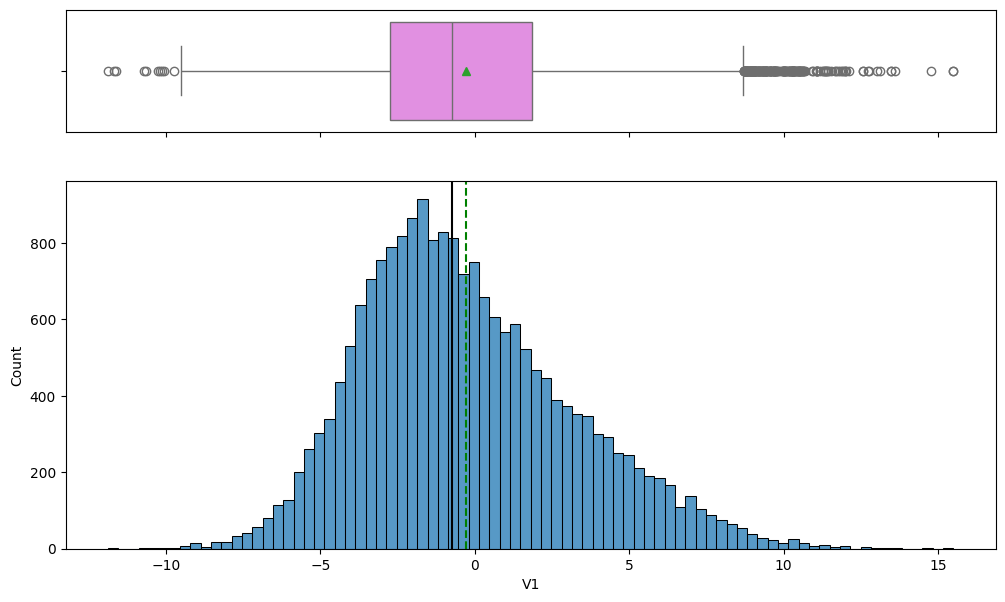

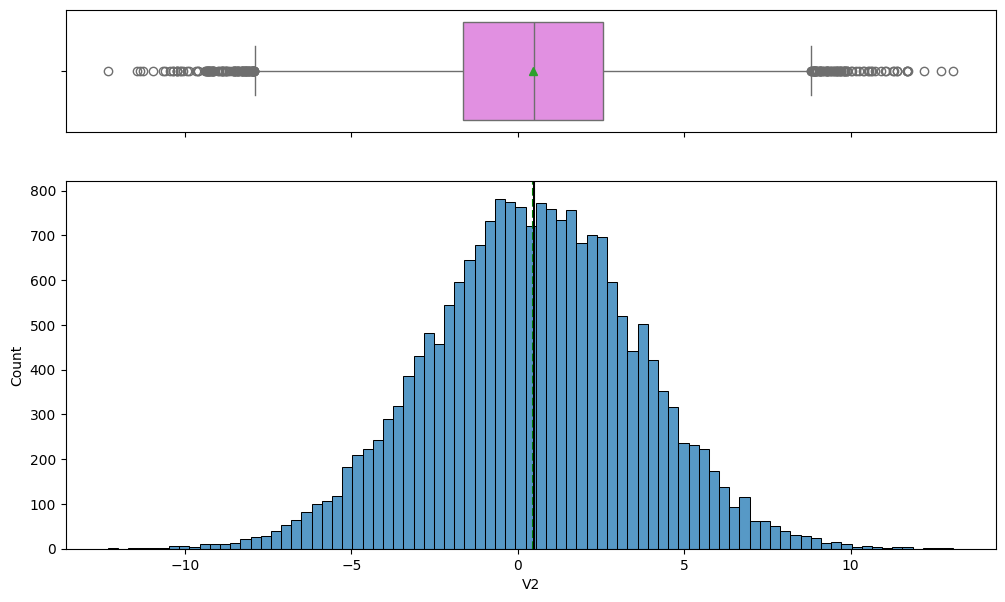

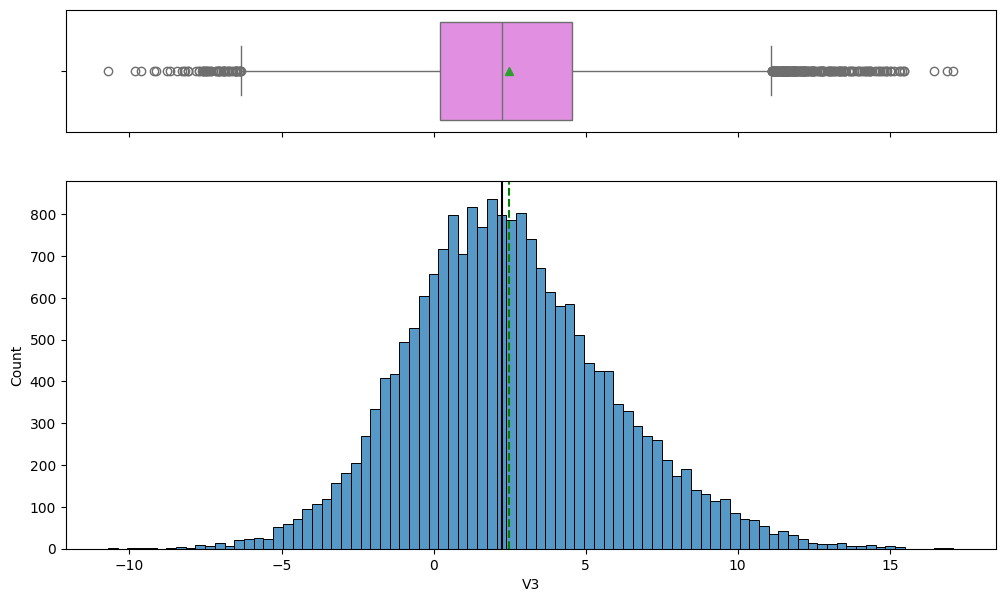

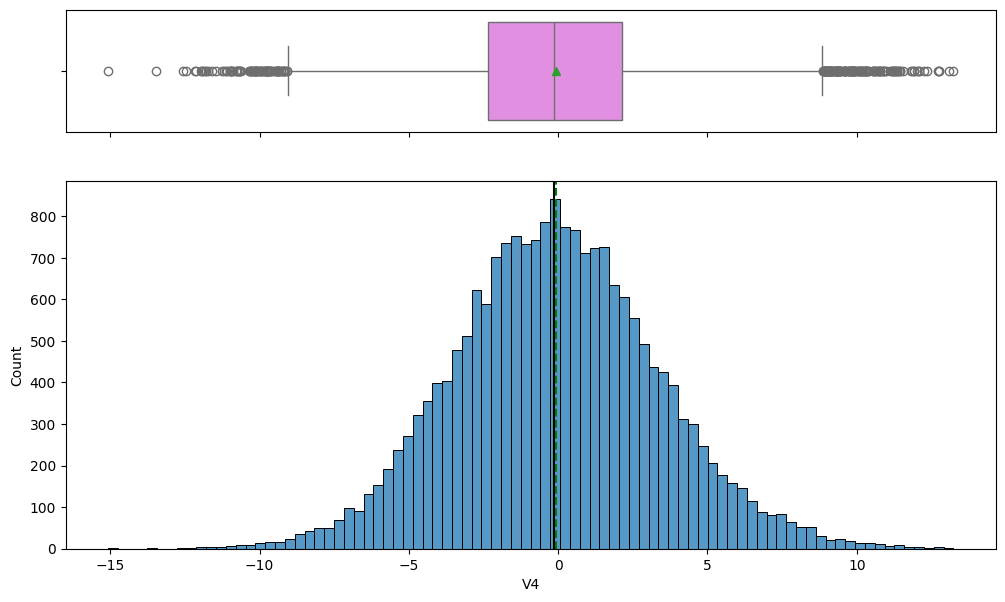

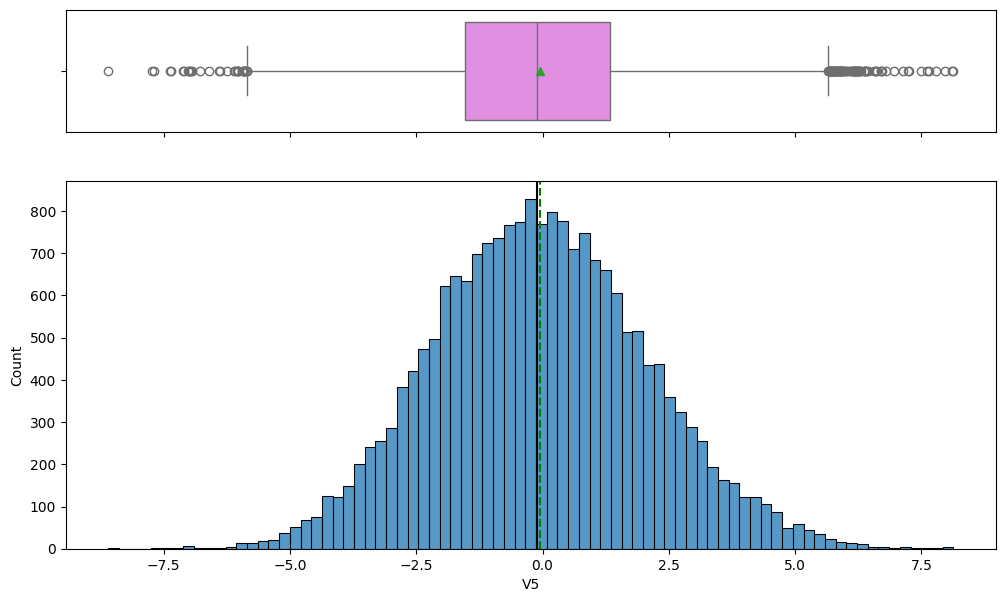

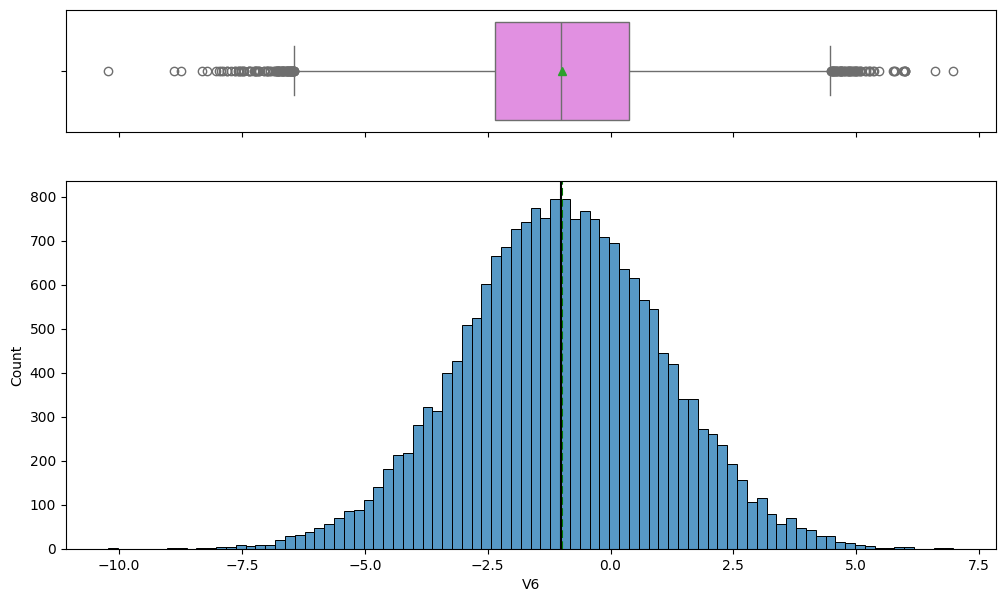

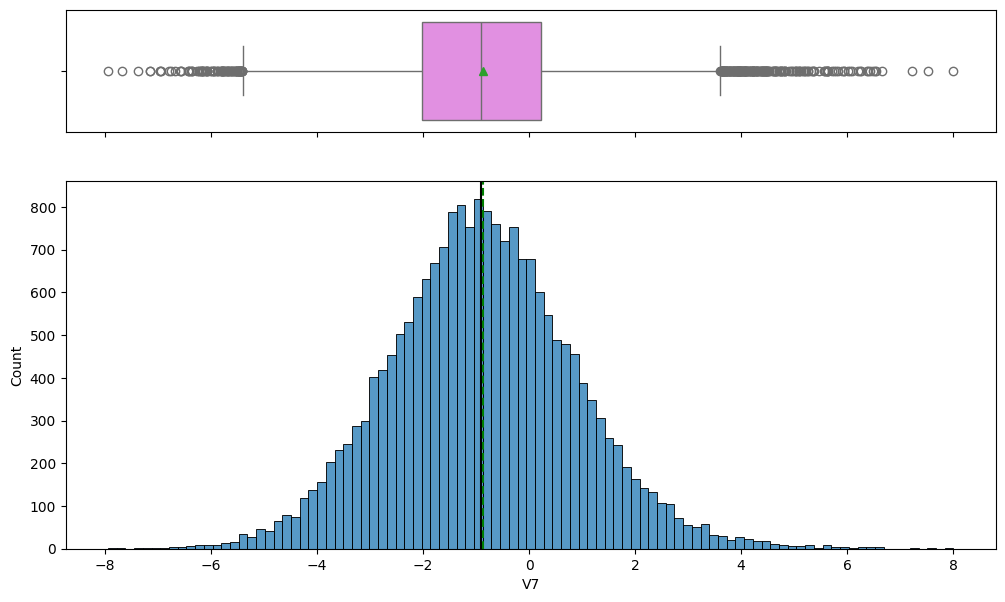

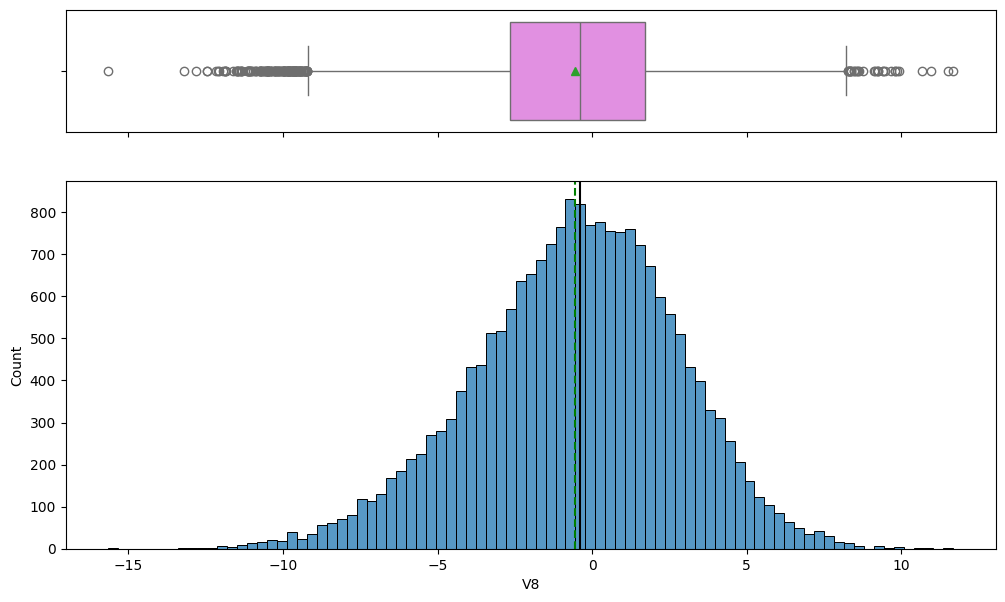

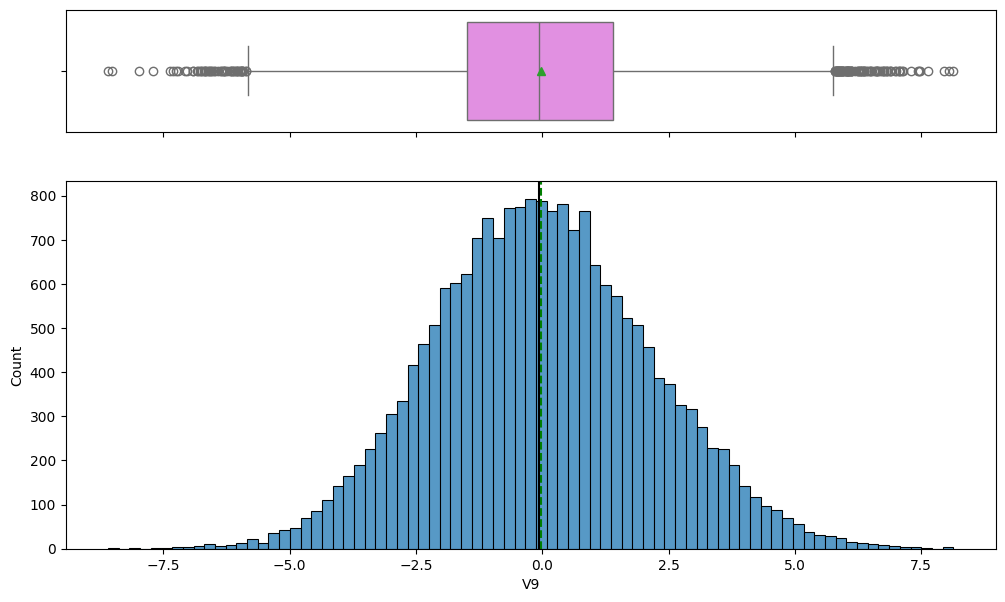

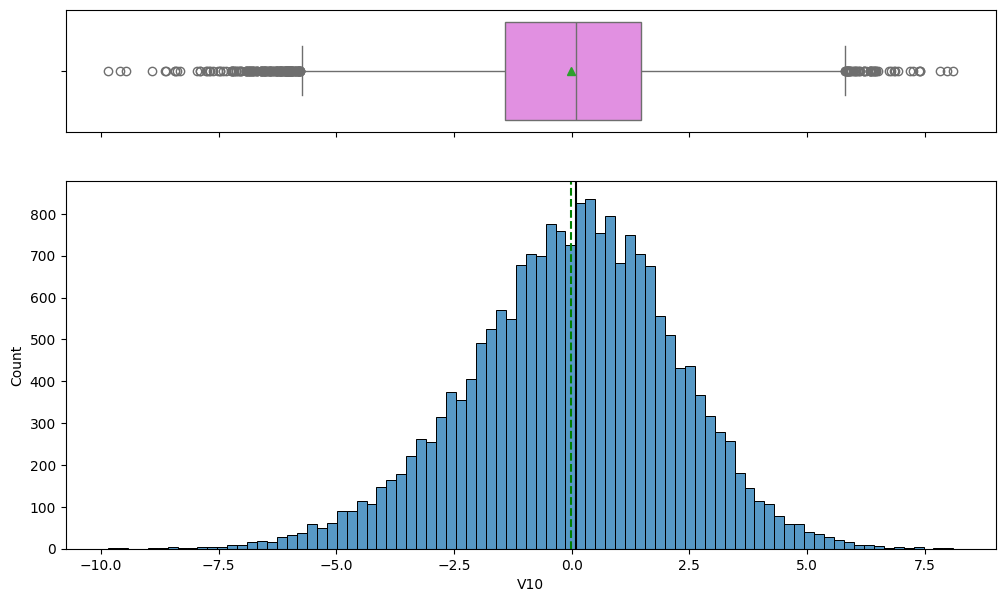

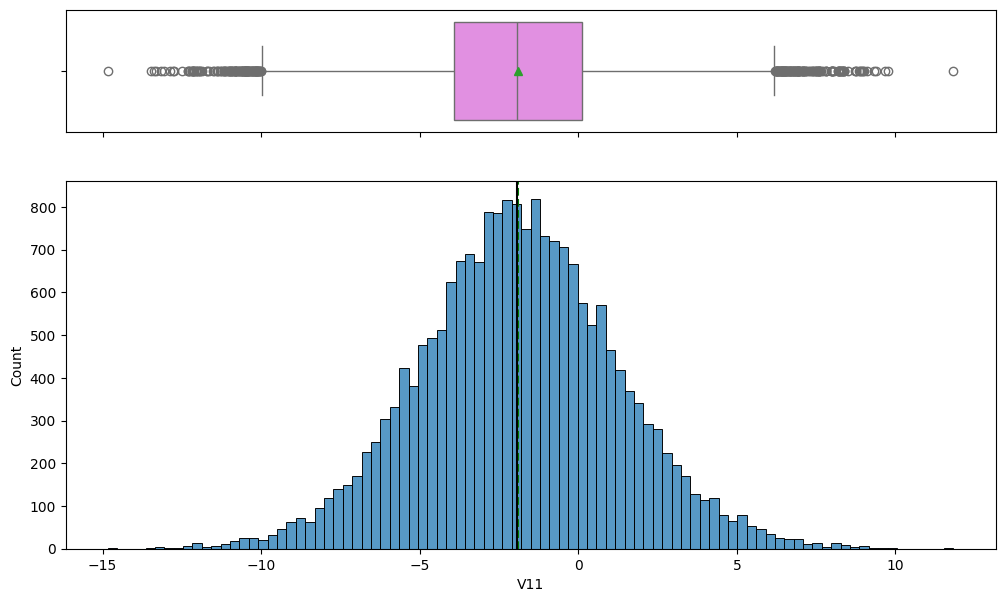

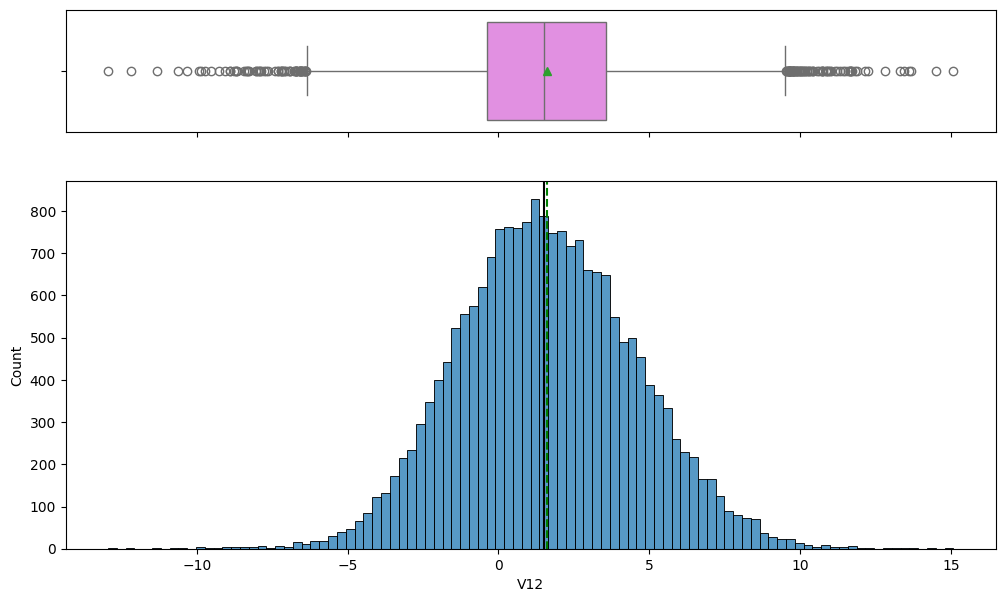

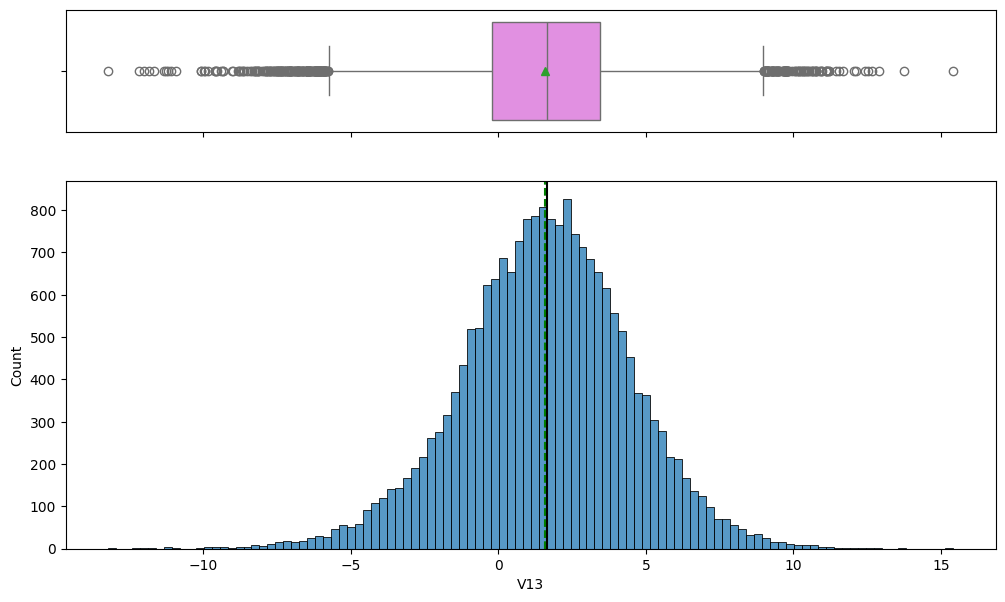

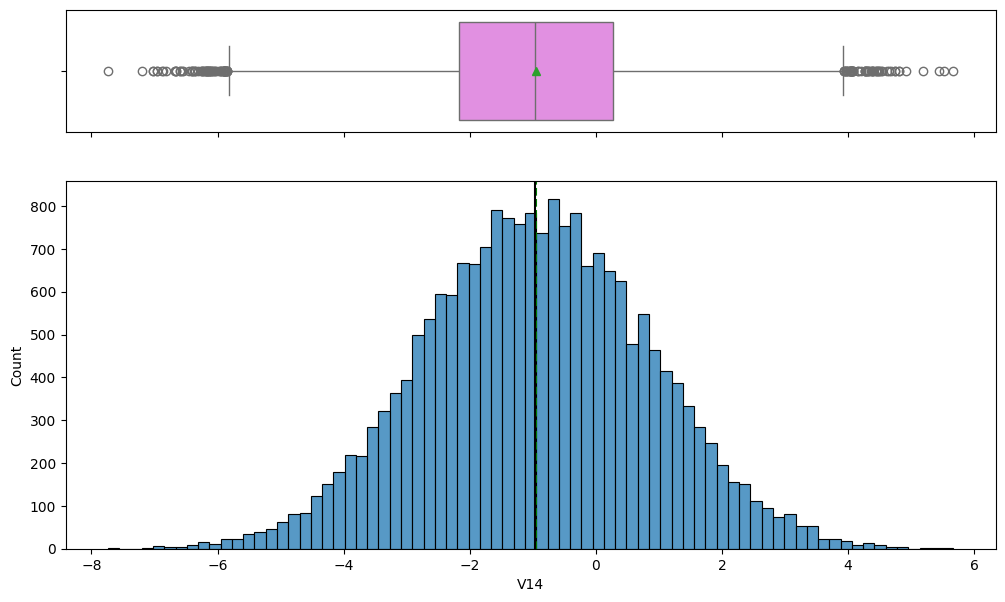

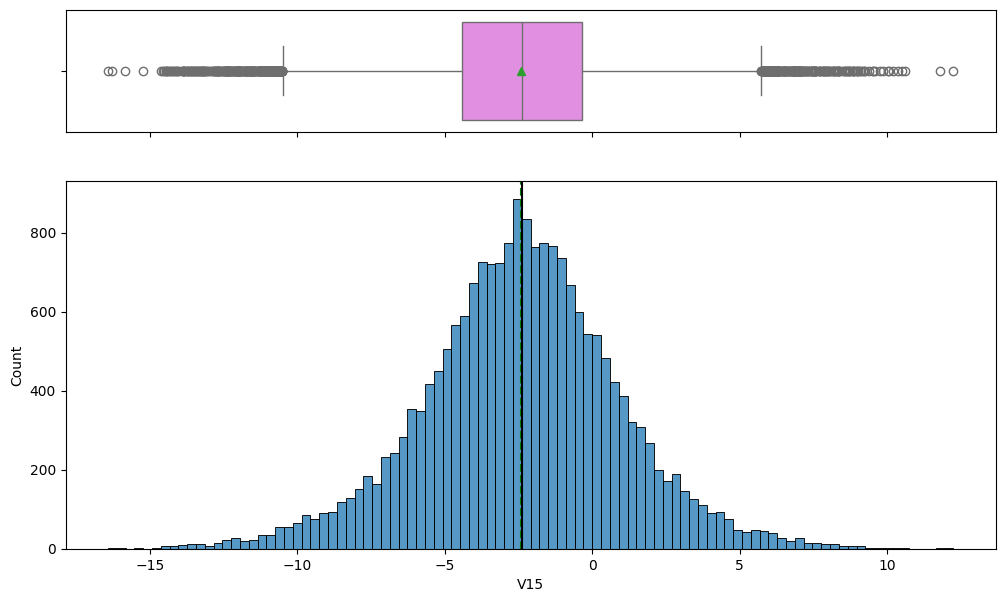

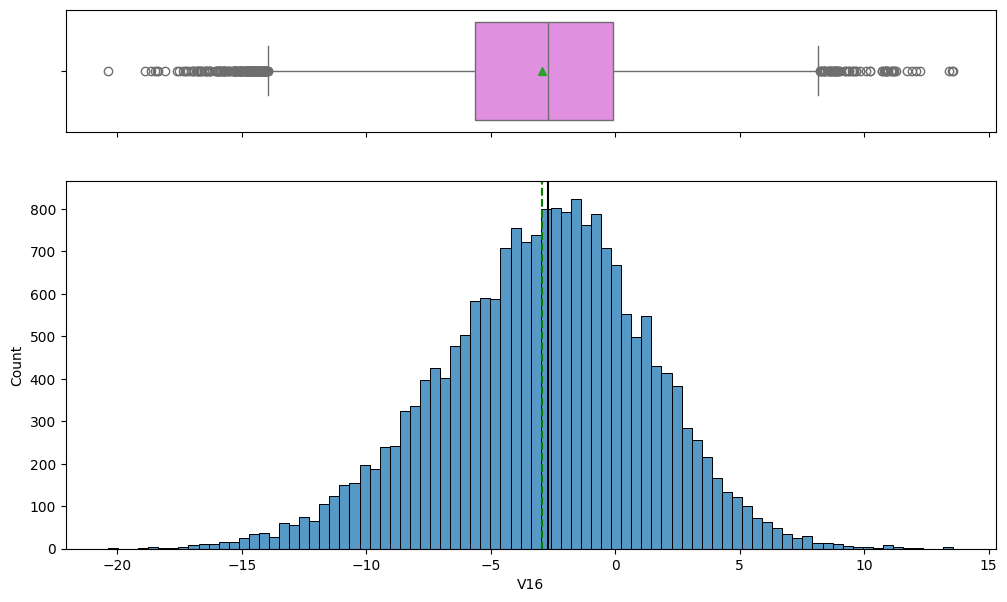

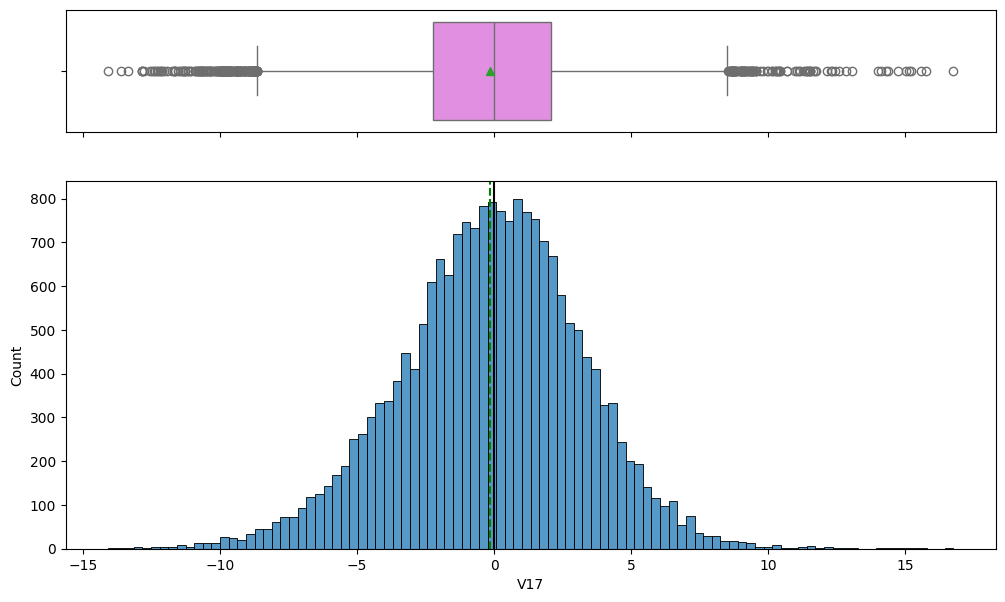

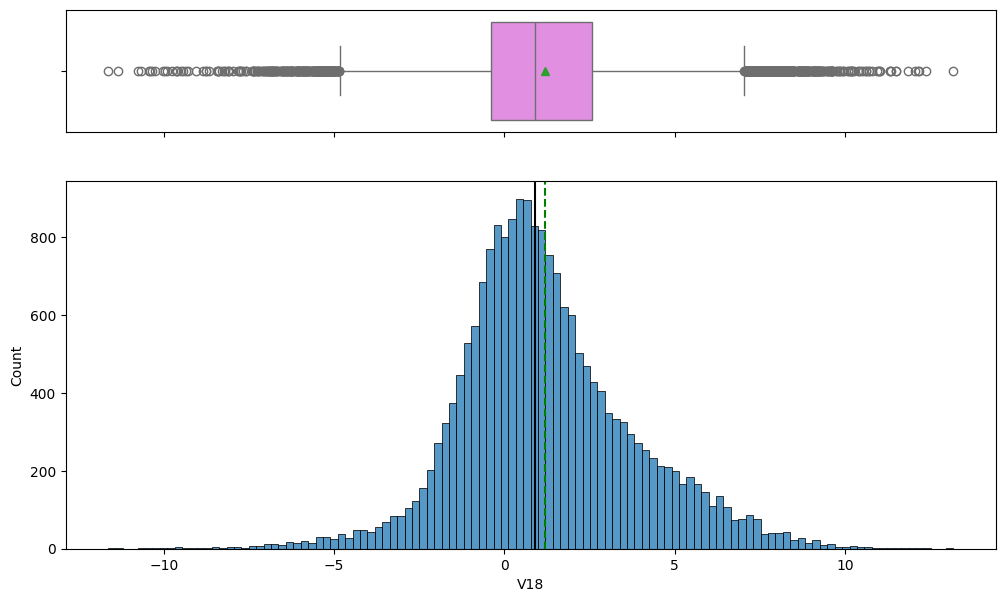

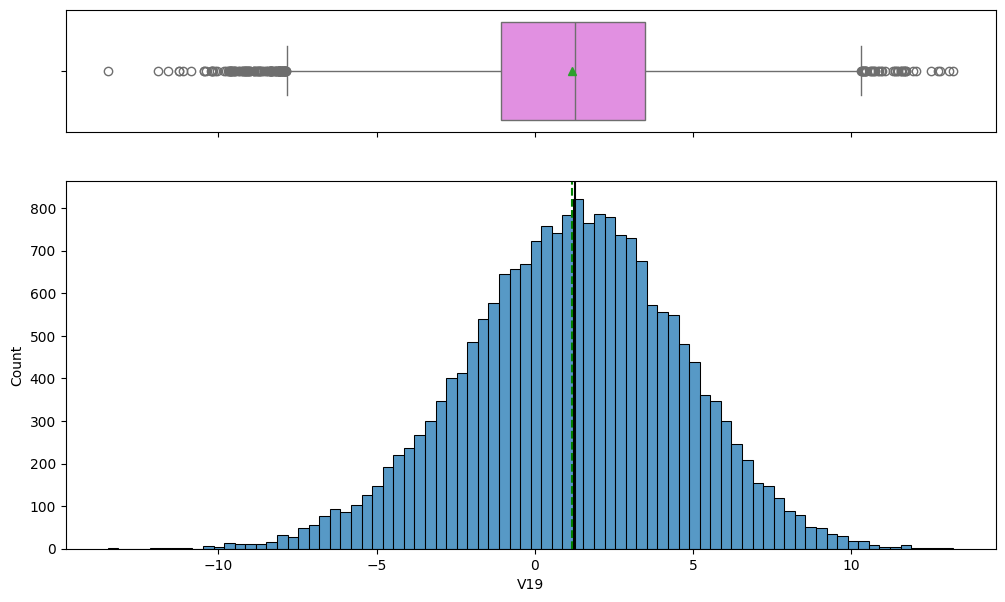

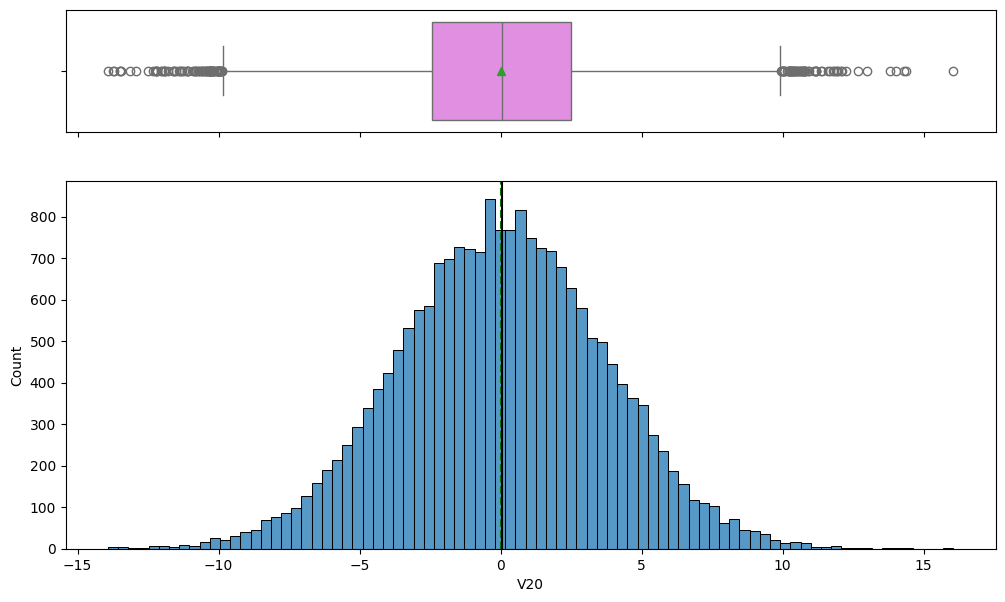

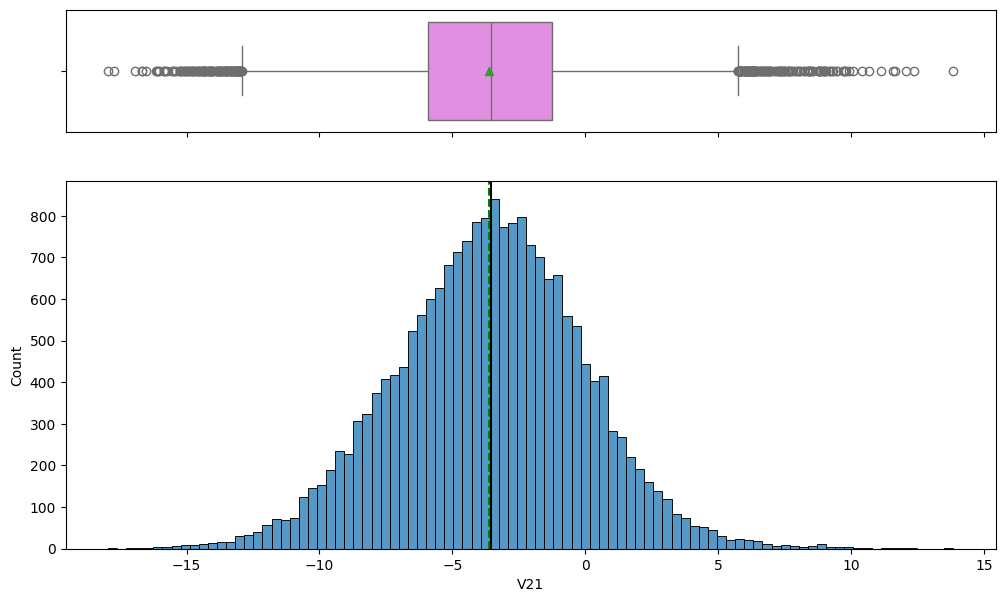

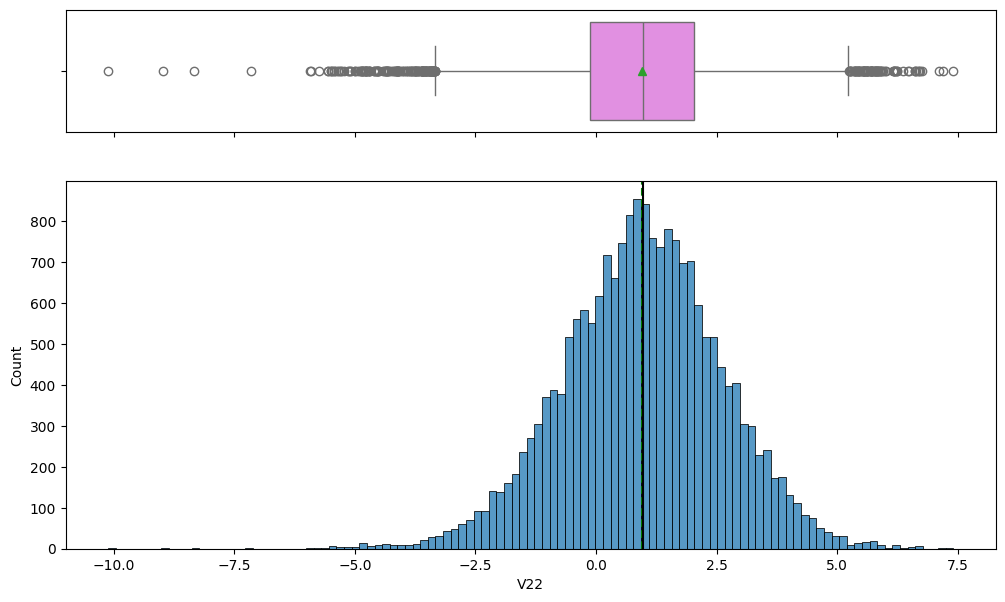

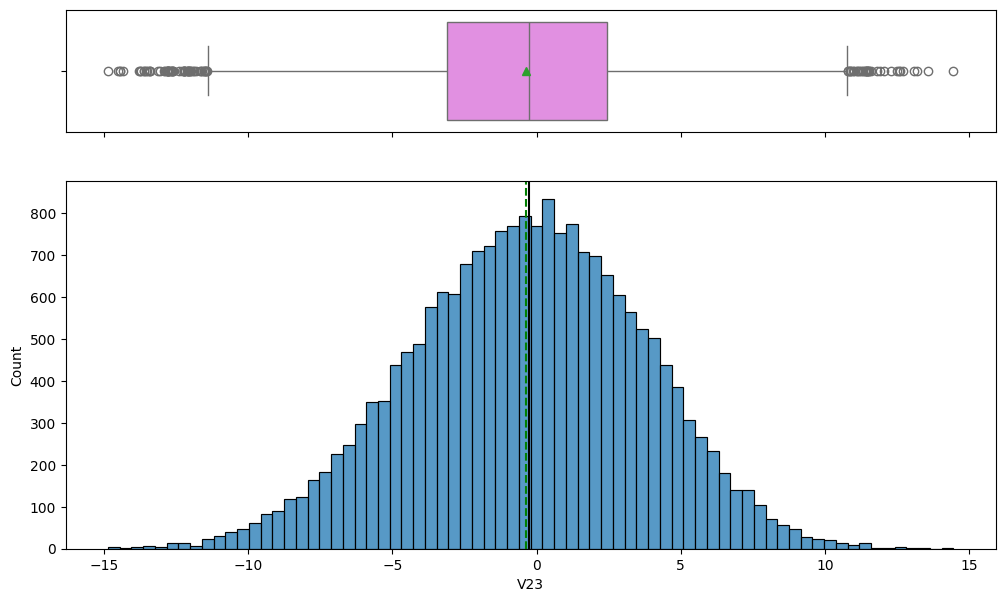

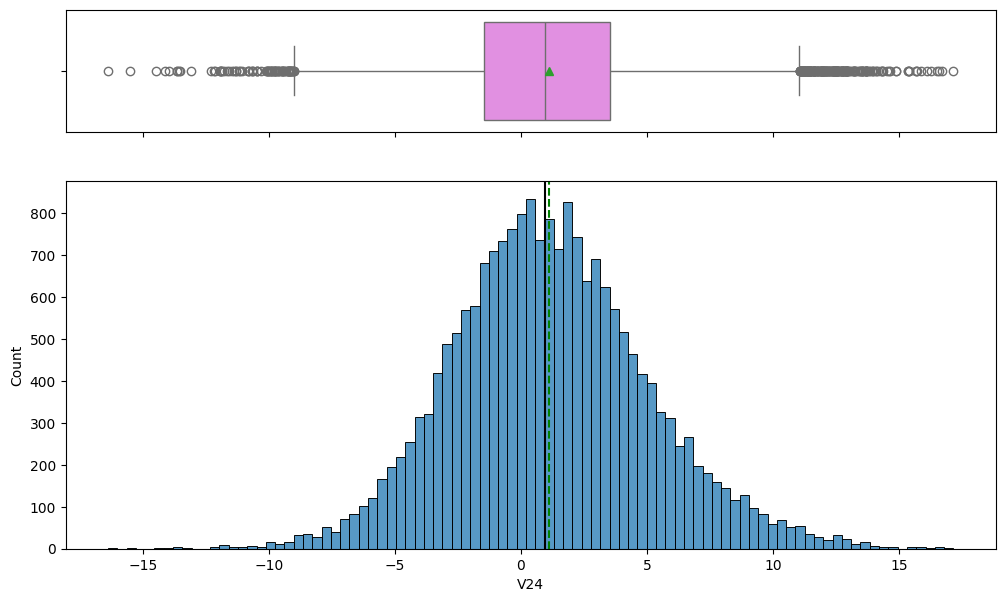

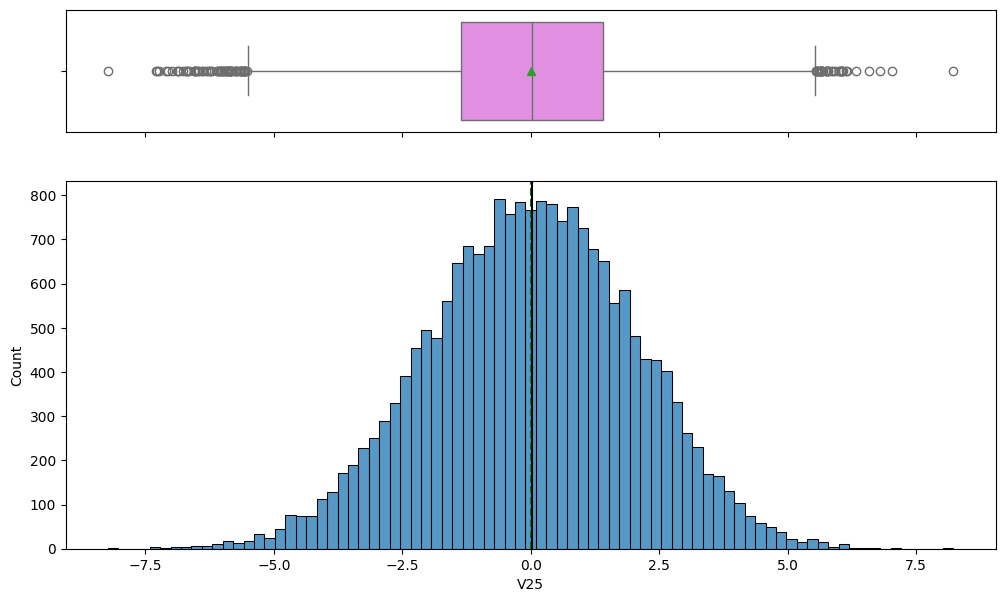

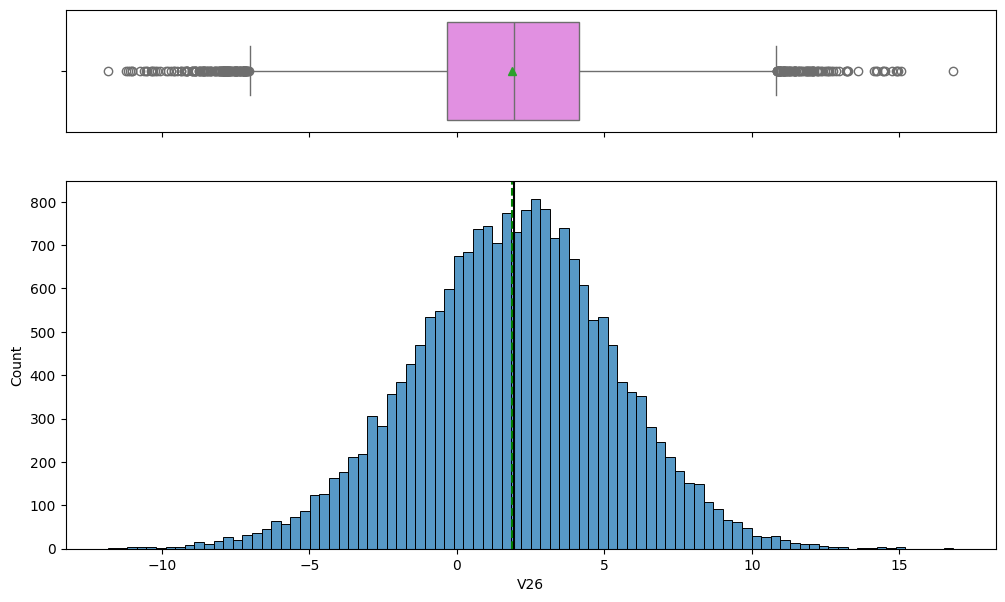

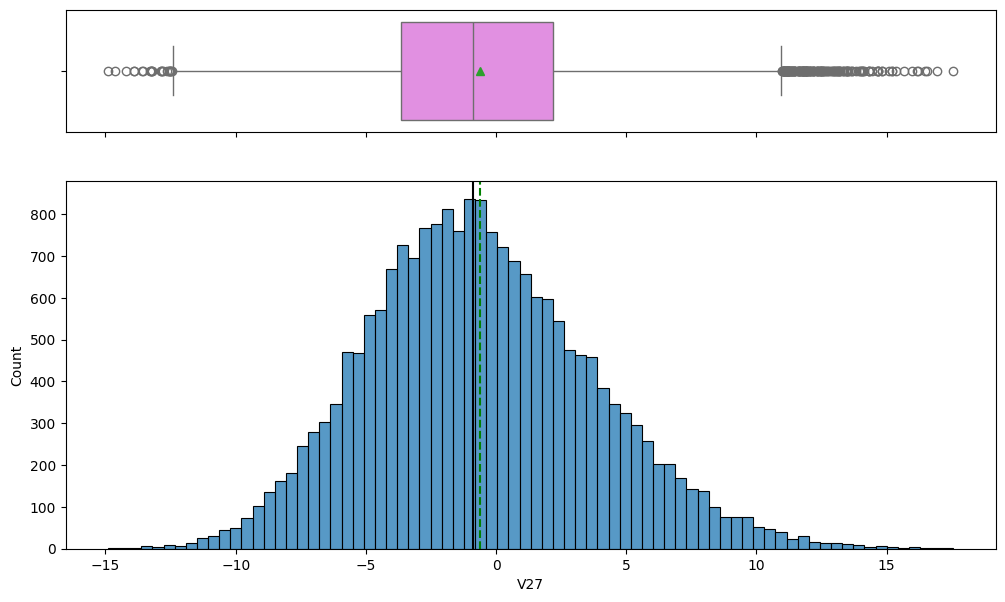

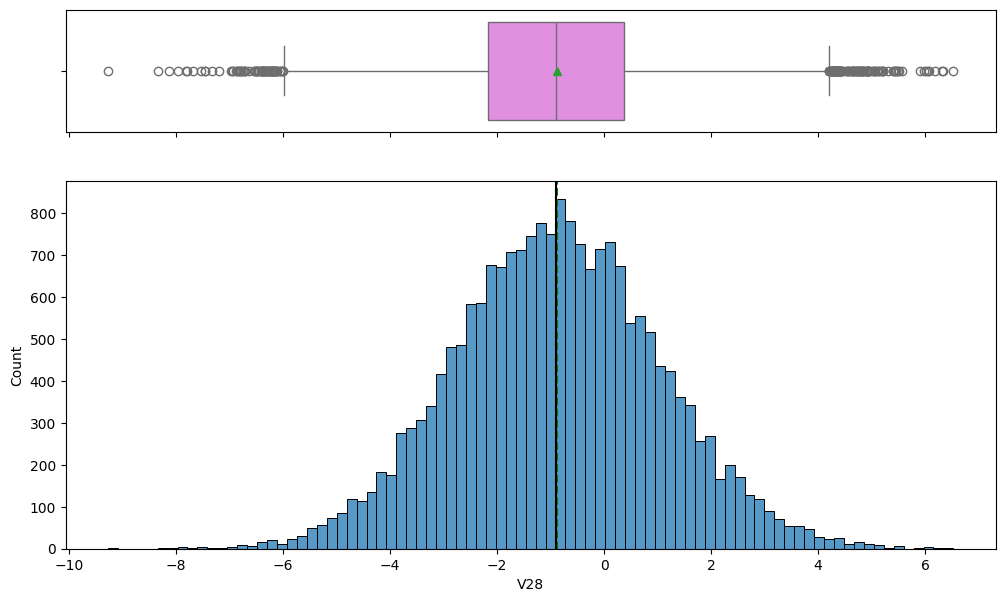

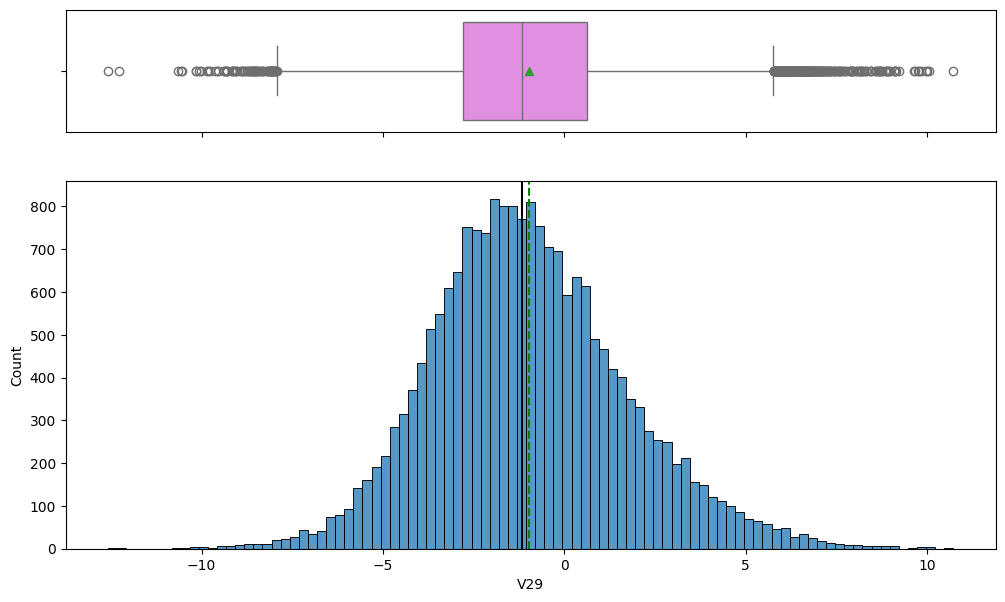

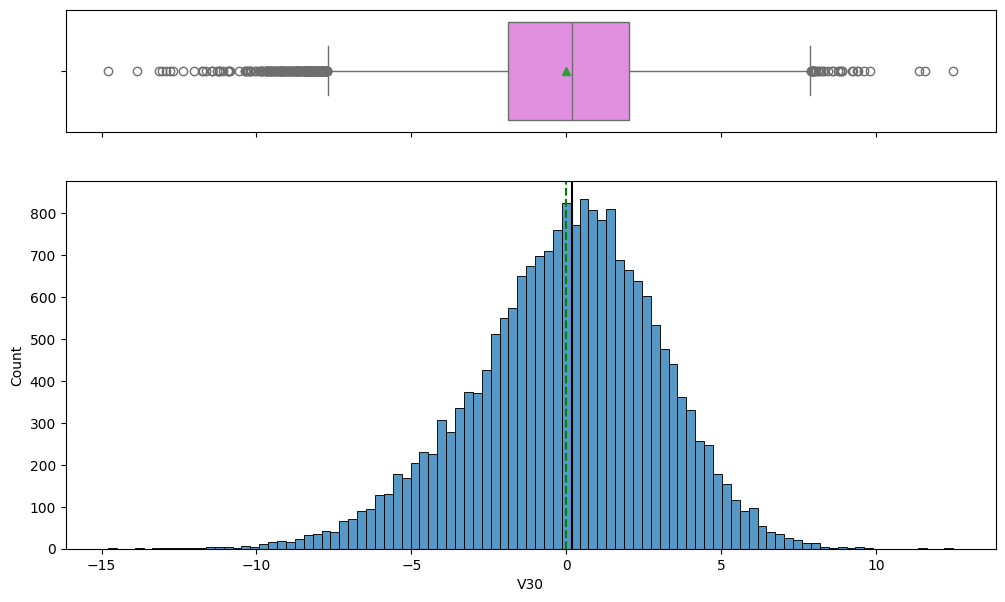

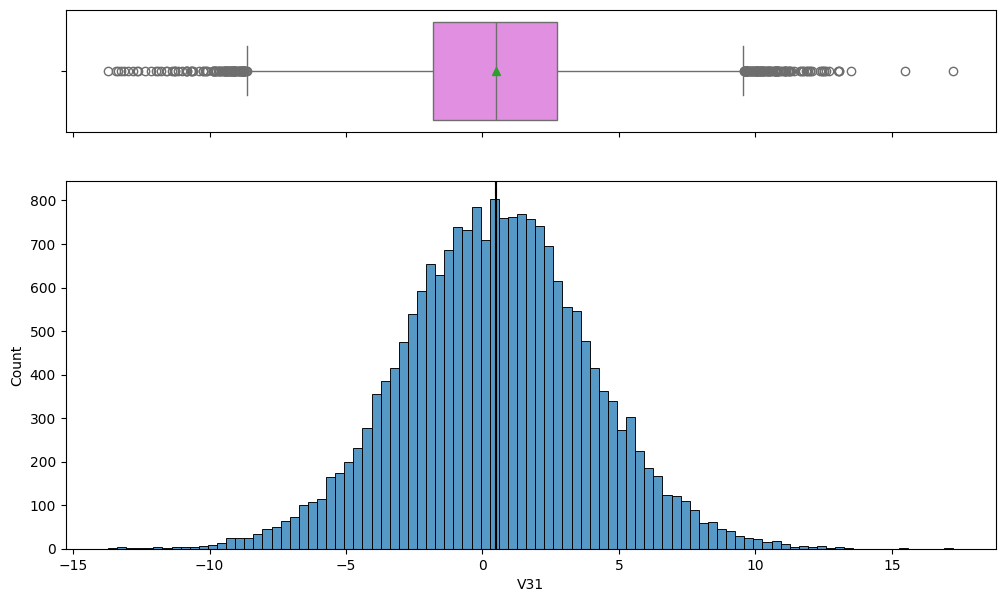

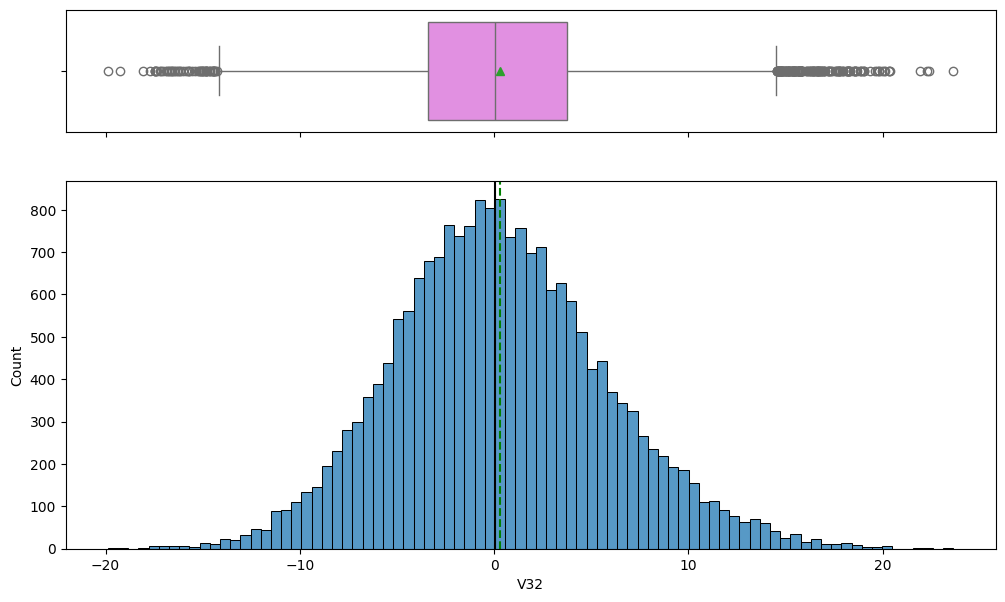

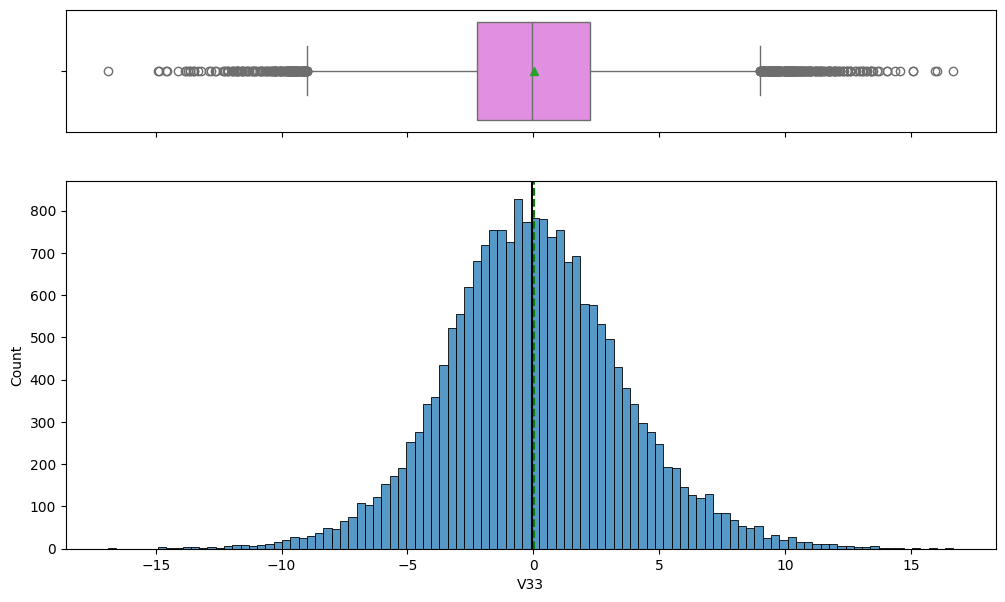

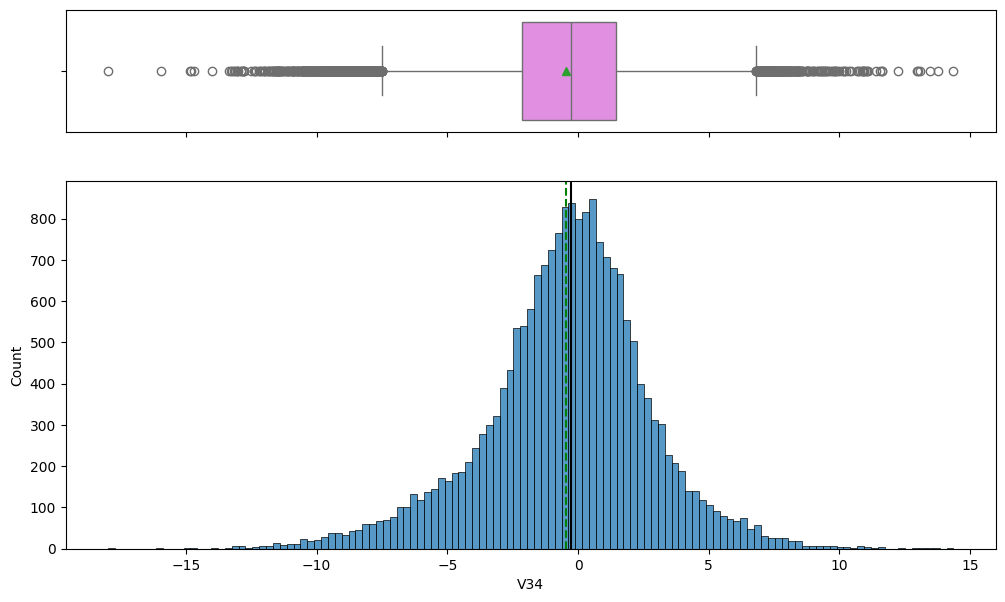

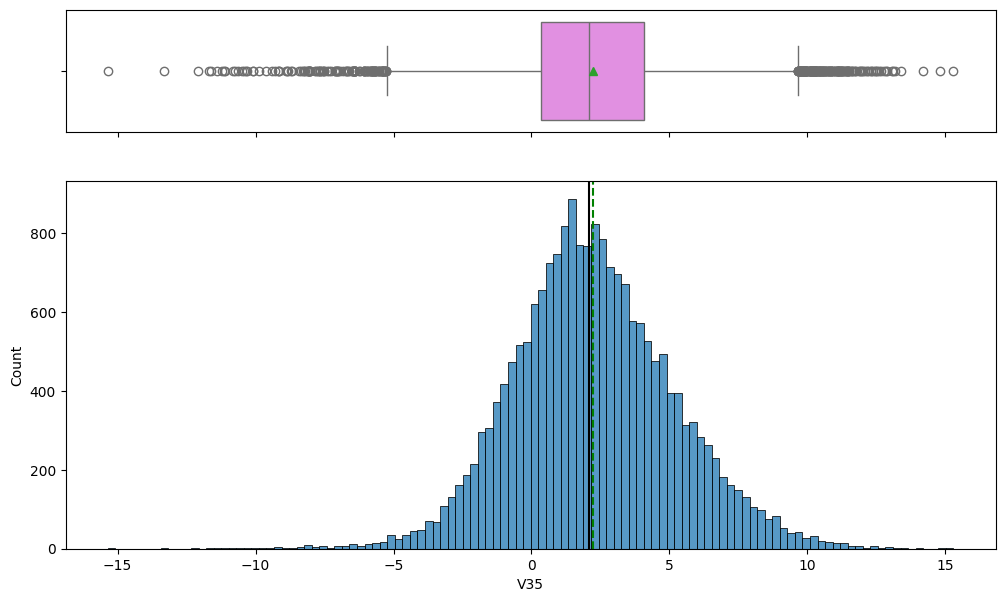

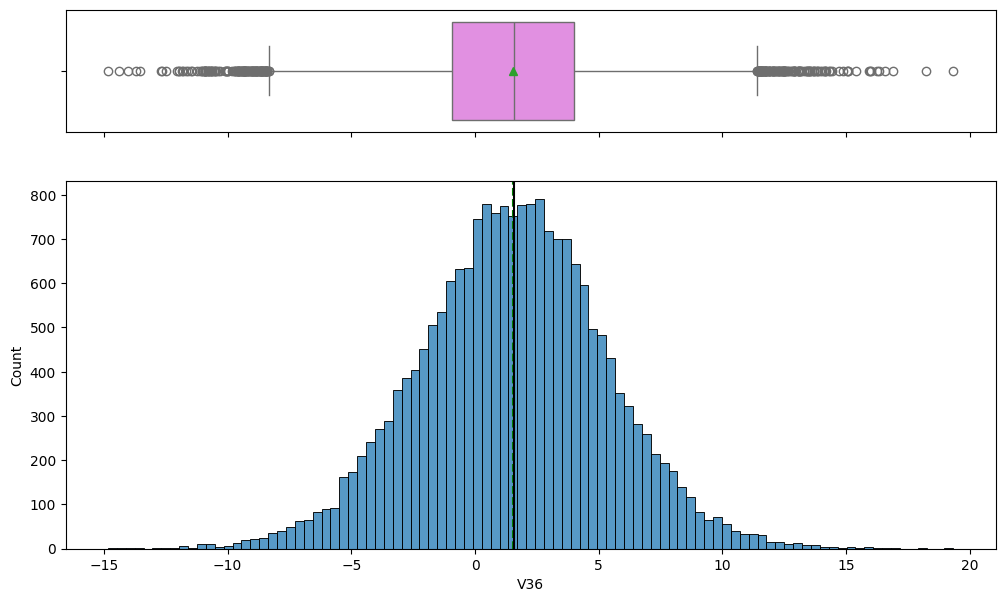

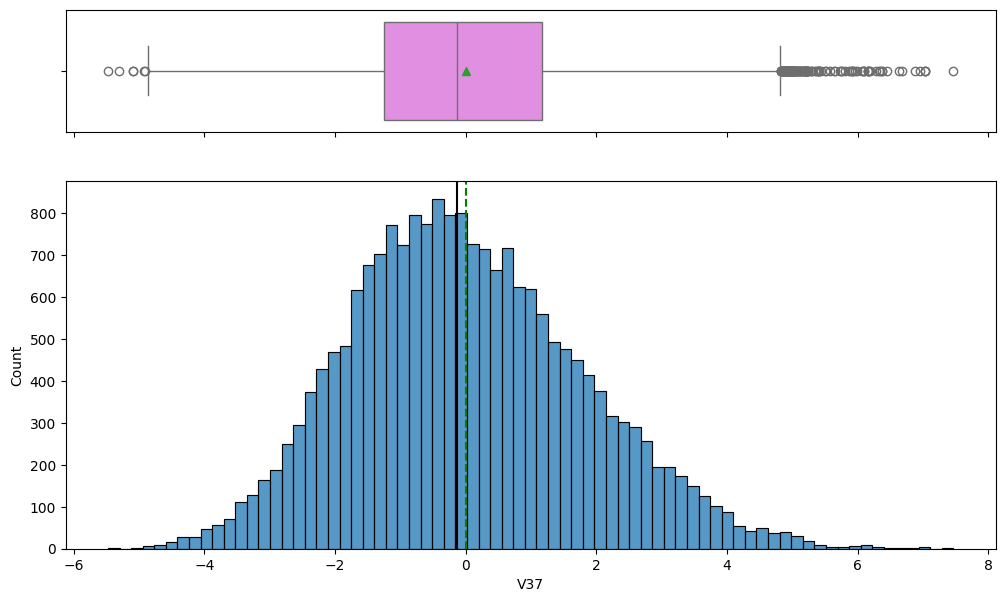

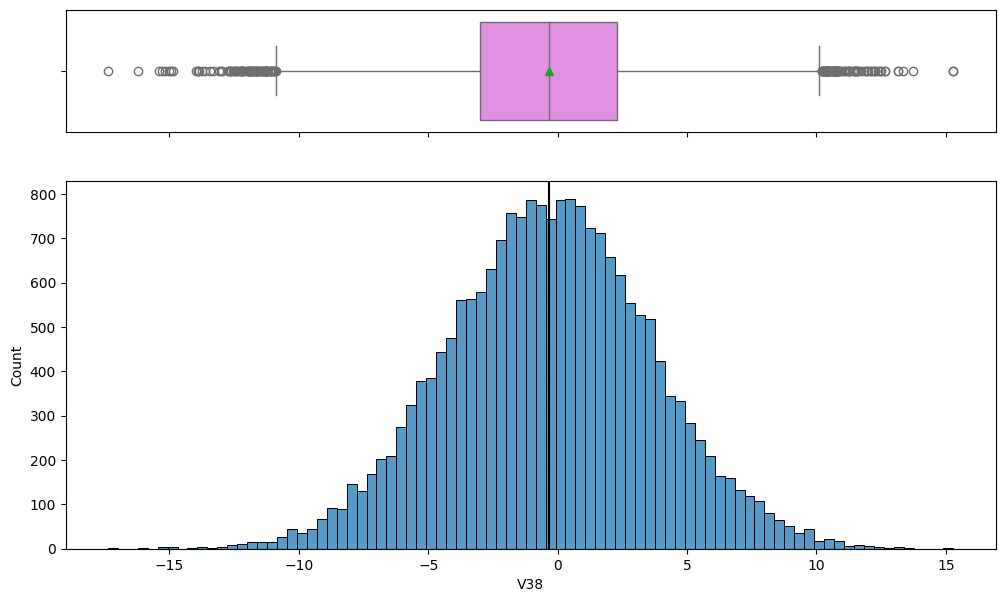

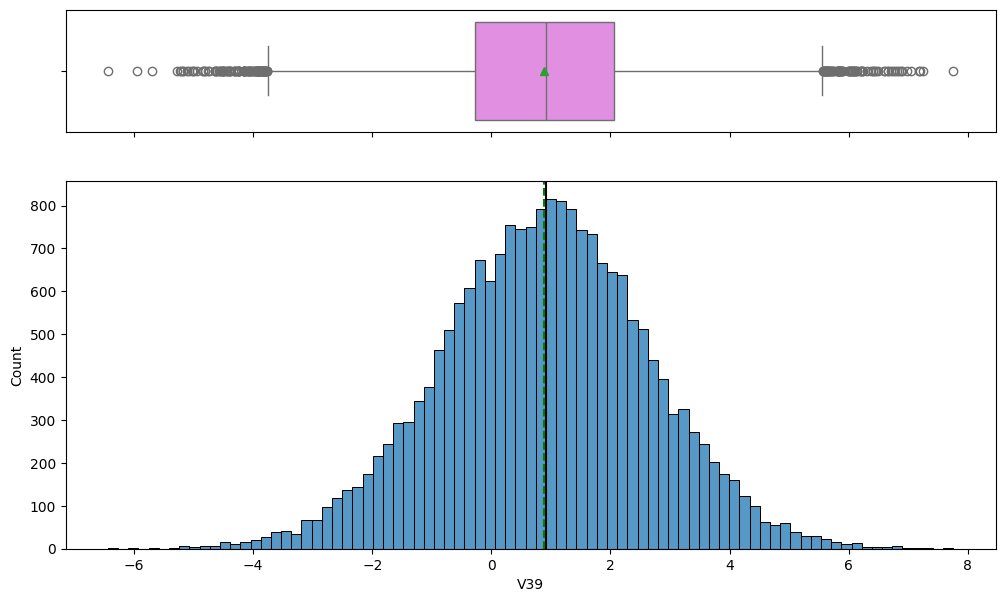

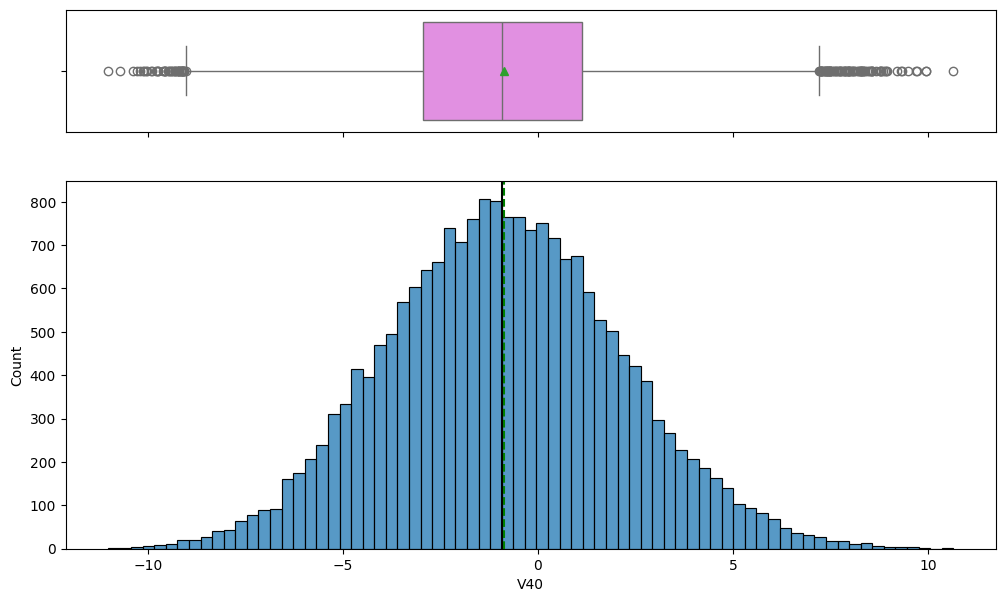

In [16]:
# plot the histogram and boxplot for all the columns
independent_variables = data.columns.tolist()[:-1]
for col in independent_variables:
    histogram_boxplot(data, col)

- Each features has outliers at both side.
- Many features have extreme min/max values compared to their quartiles:
- V16 → Min = -20.37, Max = 13.58, while 25% = -5.63 and 75% = -0.095 → strong outliers on both sides.
- V32 → Range = -19.87 to 23.63, with median = 3.76 → wide spread, heavy outliers.
- V21 → Min = -17.95, Max = 13.84, median = -3.53 → long tails.
- Features like V5, V7, V25, V37, V39 have smaller ranges (≈ -8 to +8) and fewer extreme outliers.


## Bivariate Analysis

### Heat Map

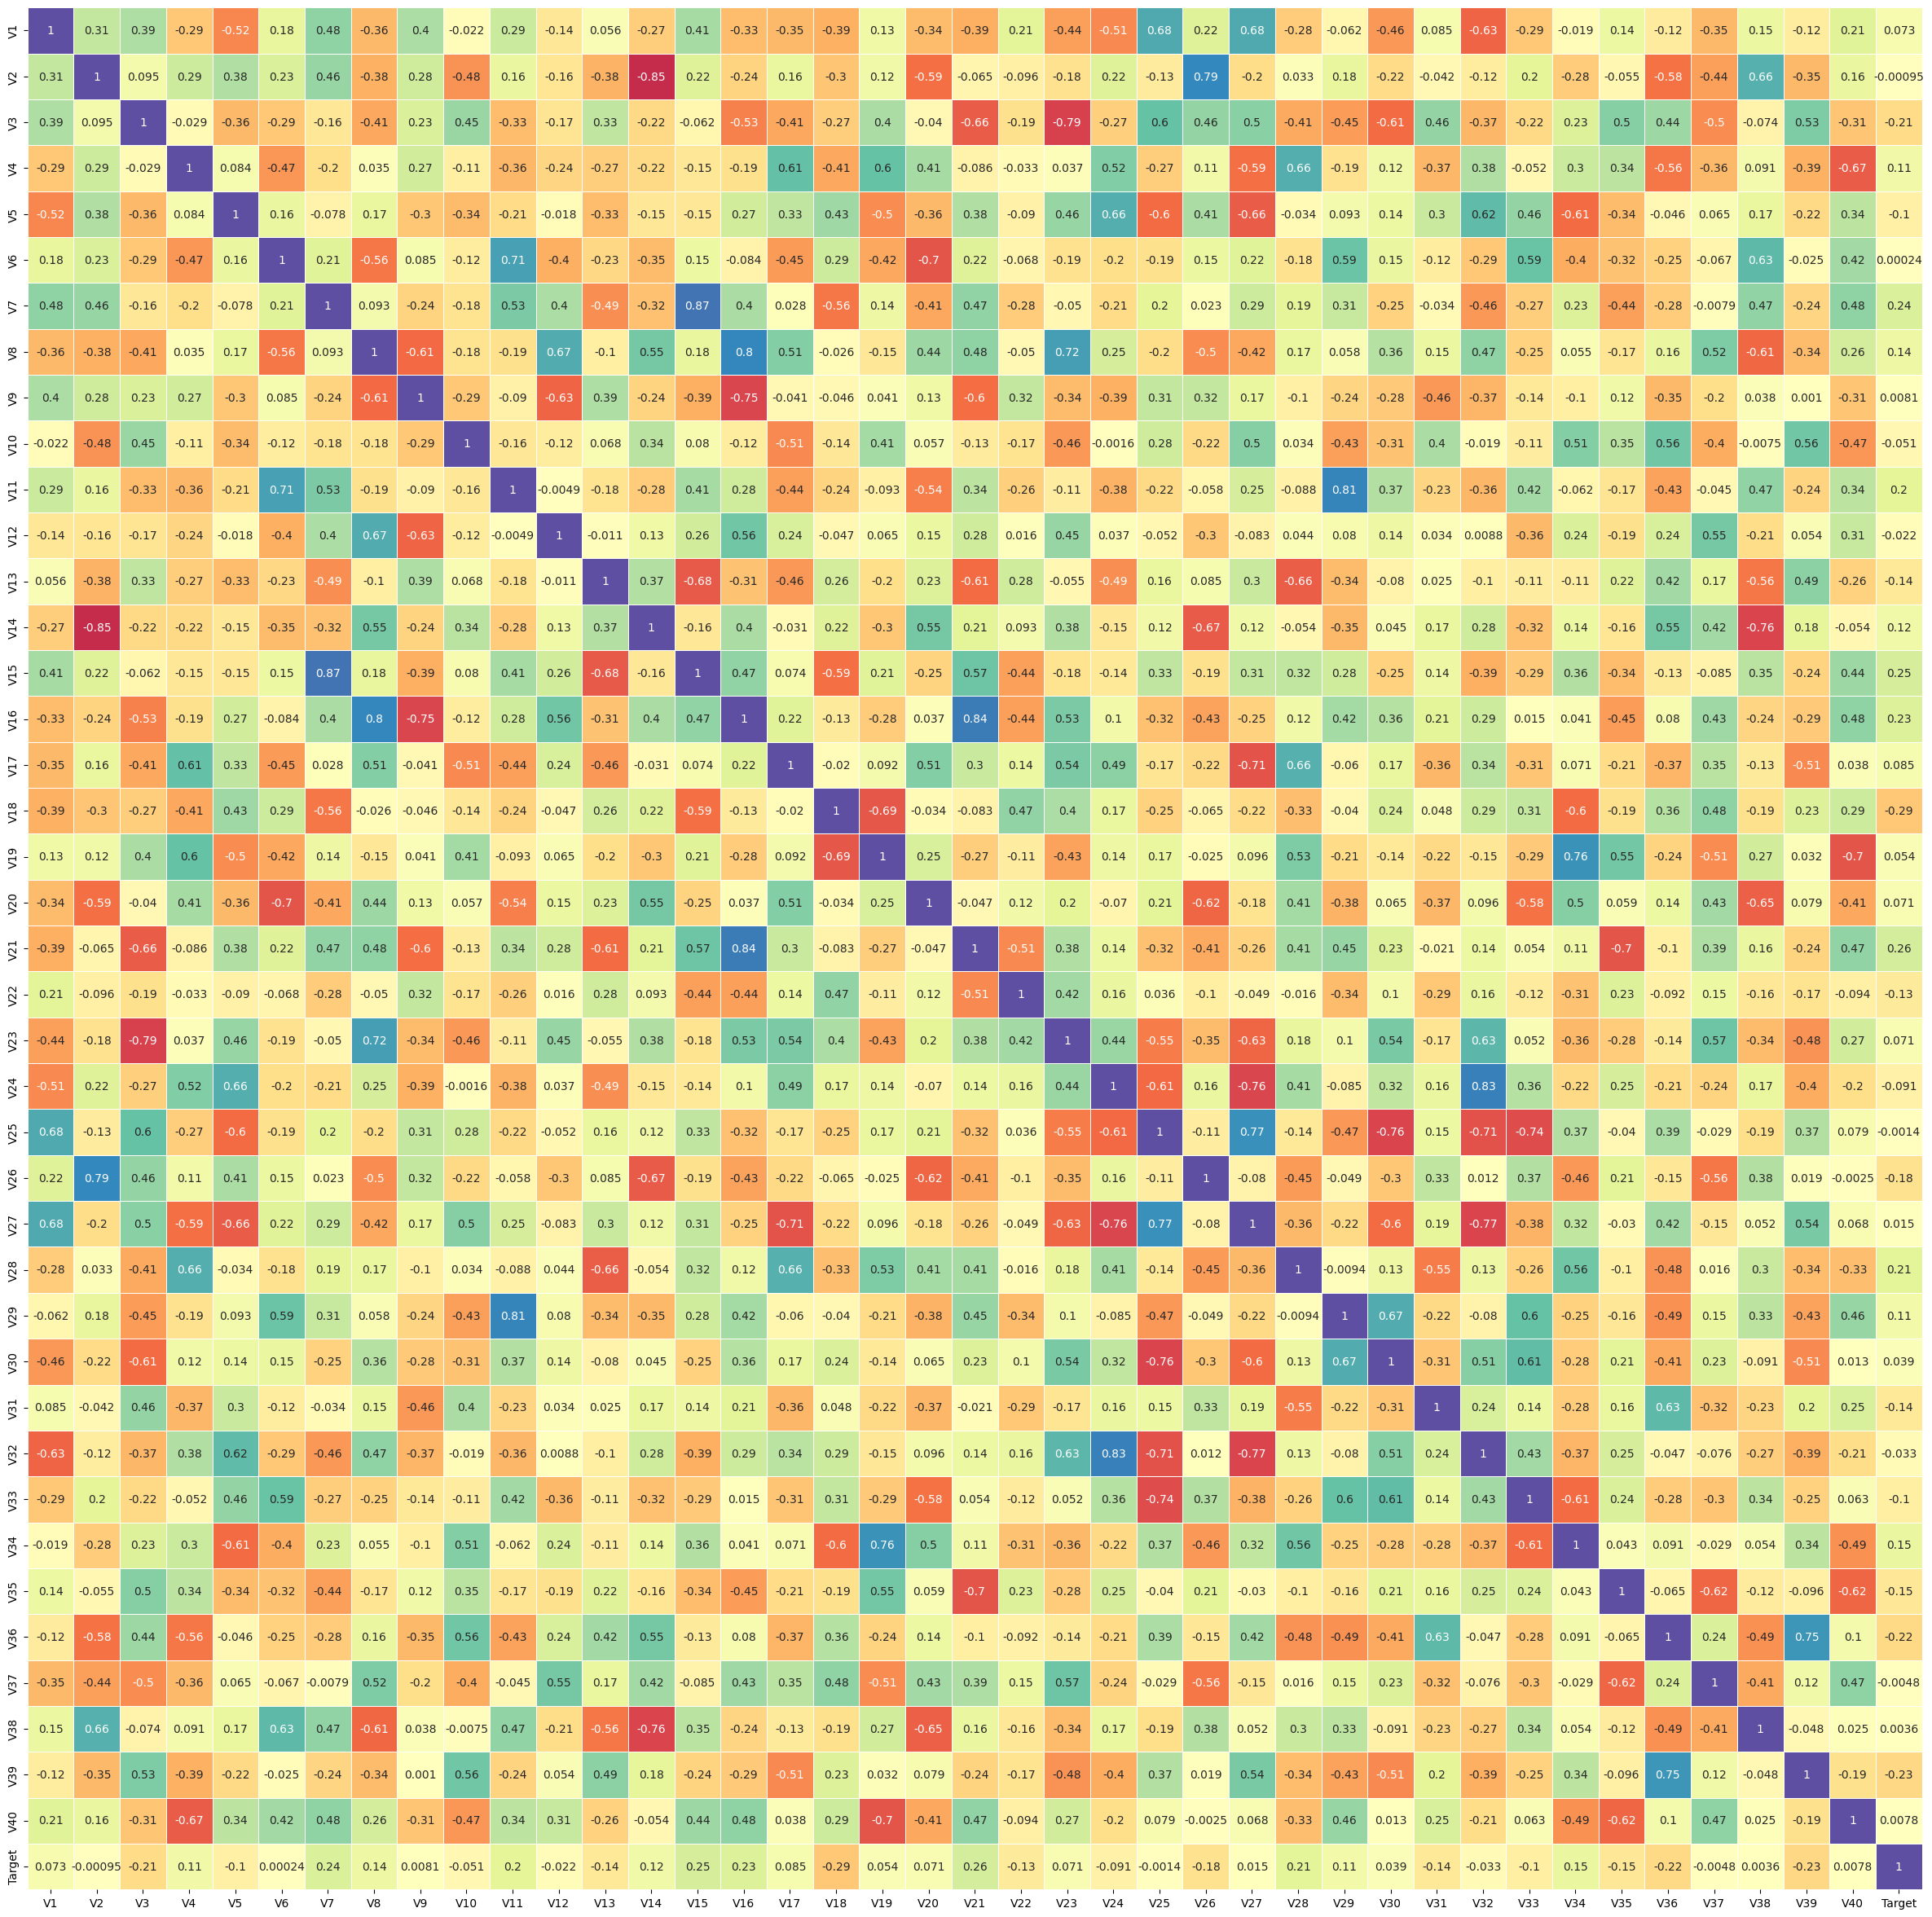

In [17]:
plt.figure(figsize=(30, 30))
sns.heatmap(data.corr(numeric_only = True),
            annot=True,
            linewidths=.5,
            center=0,
            cbar=False,
            cmap="Spectral")
plt.show()

- Many features are high correlated with each other.
- V6 and V11 are highly correlated with a correlation values of 0.71.
- V7 and V15 are highly correlated with a correlation values of 0.87.
- V8 and V16 are highly correlated with a correlation values of 0.8.
- V2 and V26 are highly correlated with a correlation values of 0.79.
- V32 and V24 are highly correlated with a correlation values of 0.83.

### Observation of Indenedent variable vs target variable

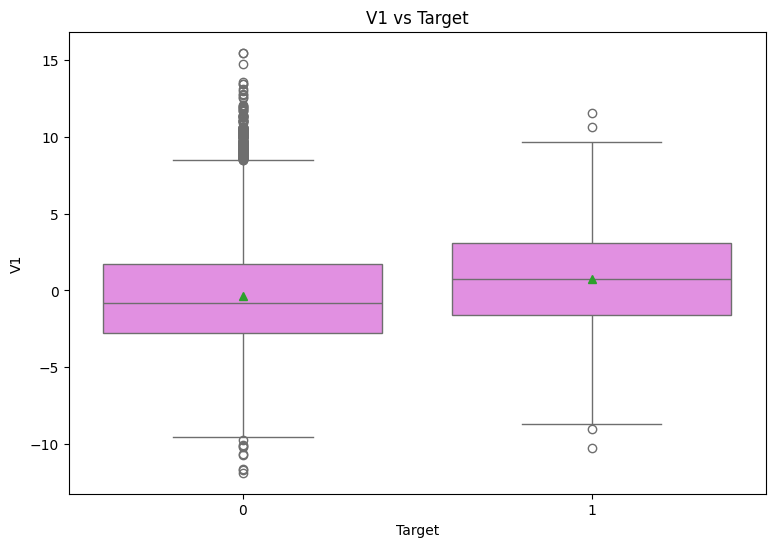

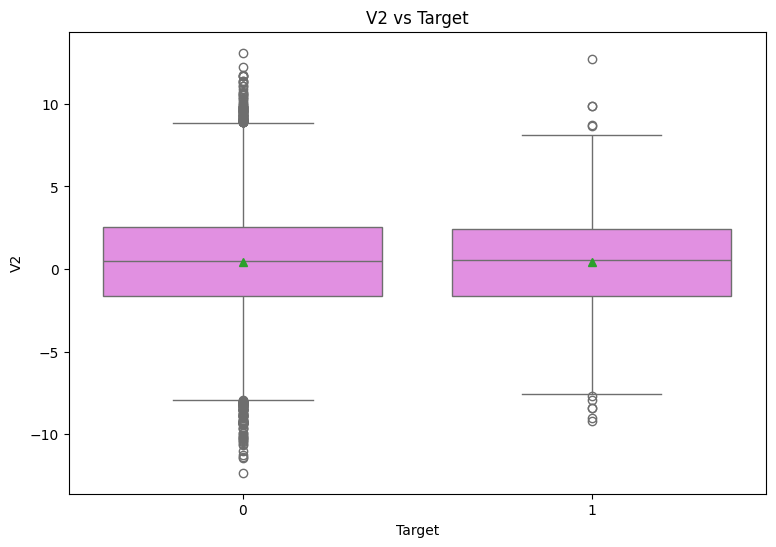

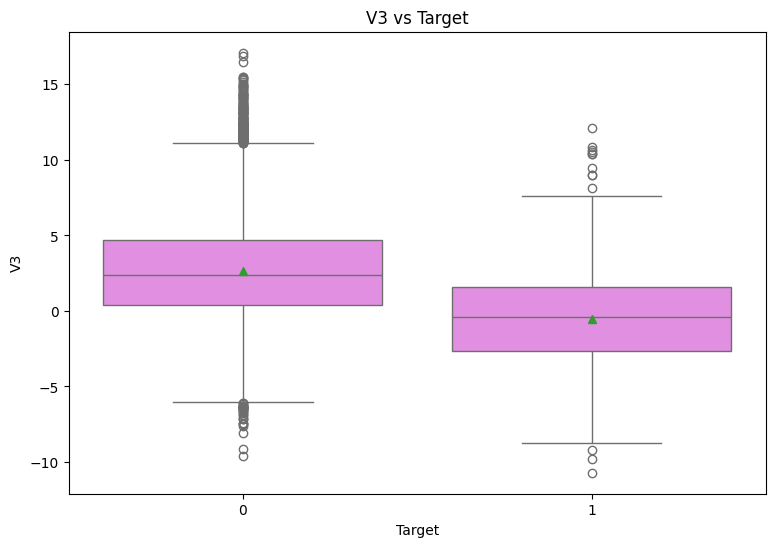

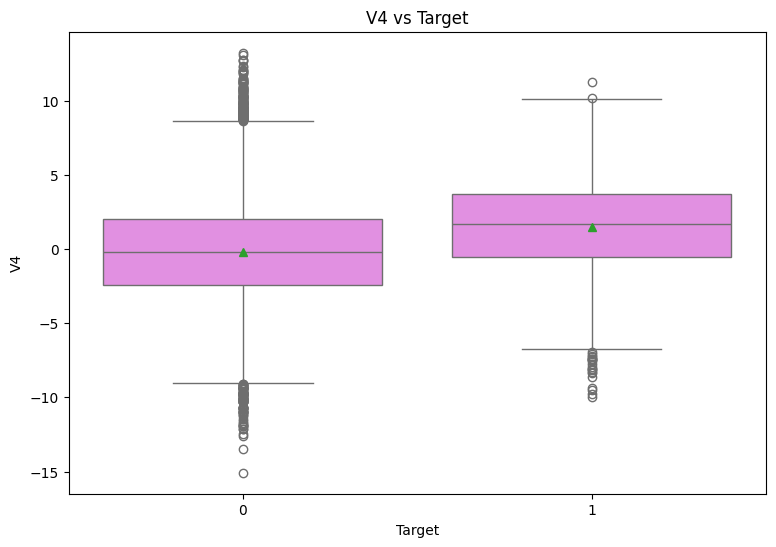

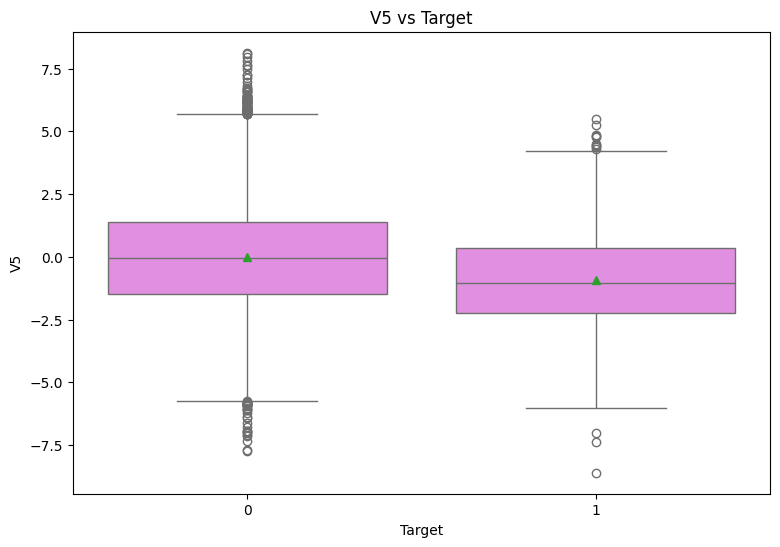

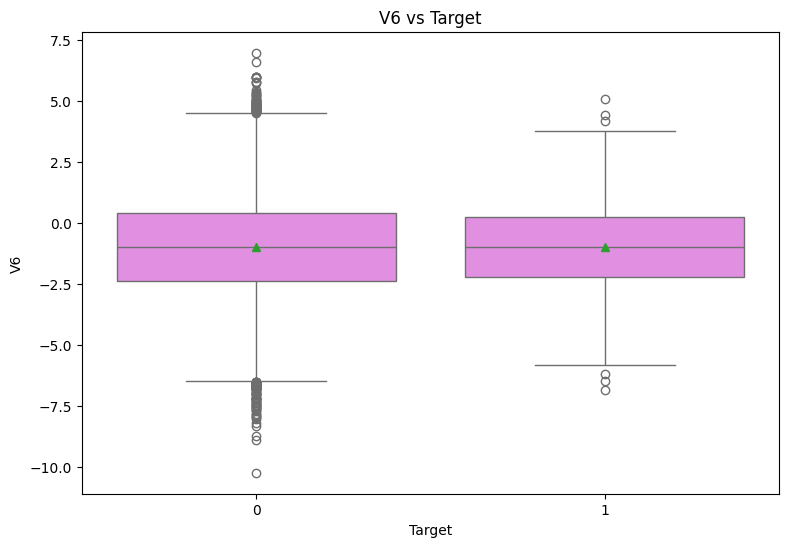

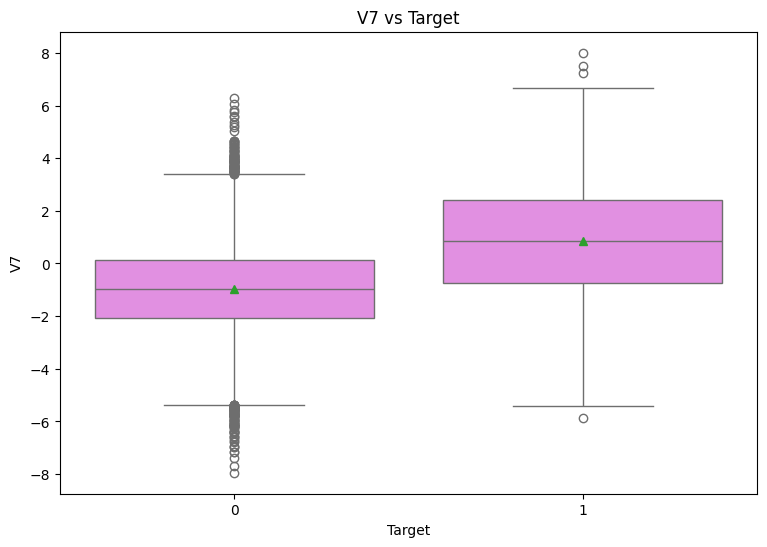

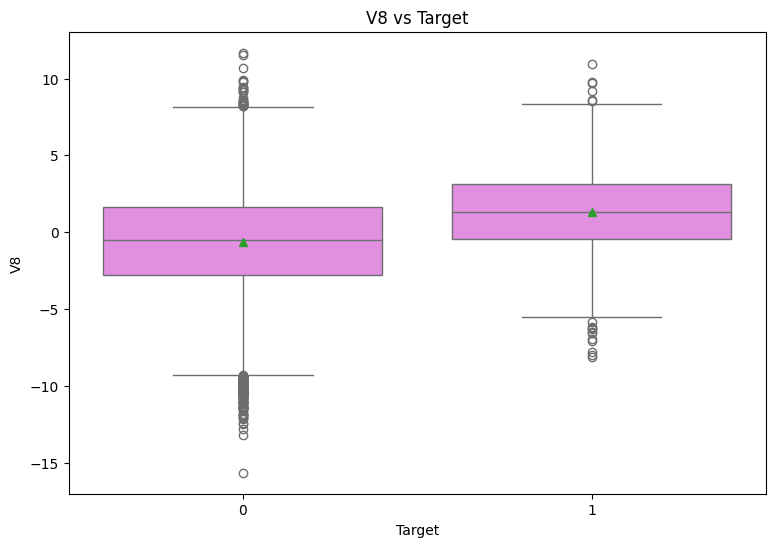

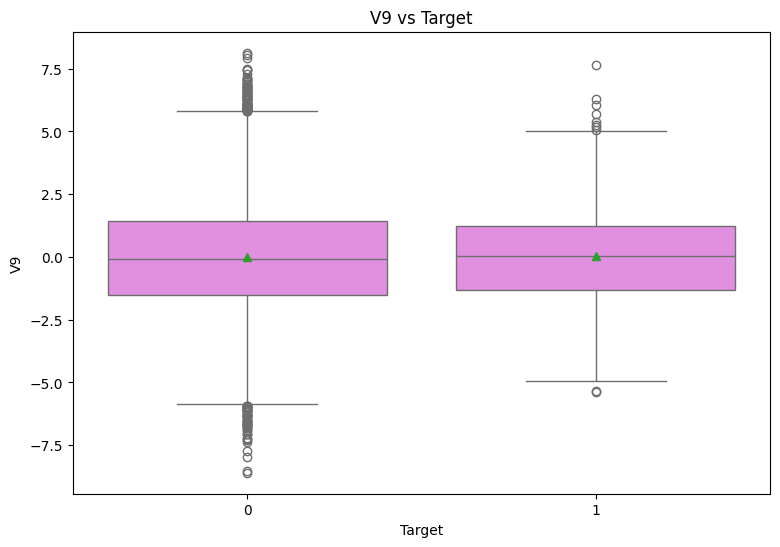

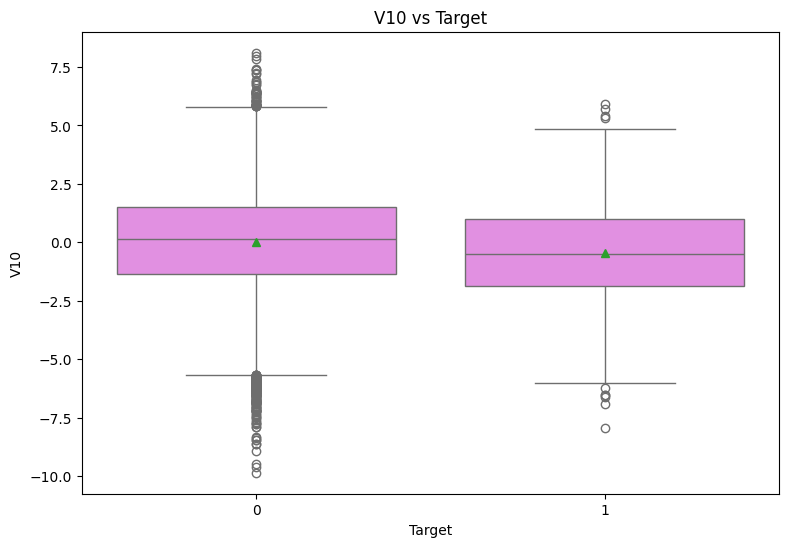

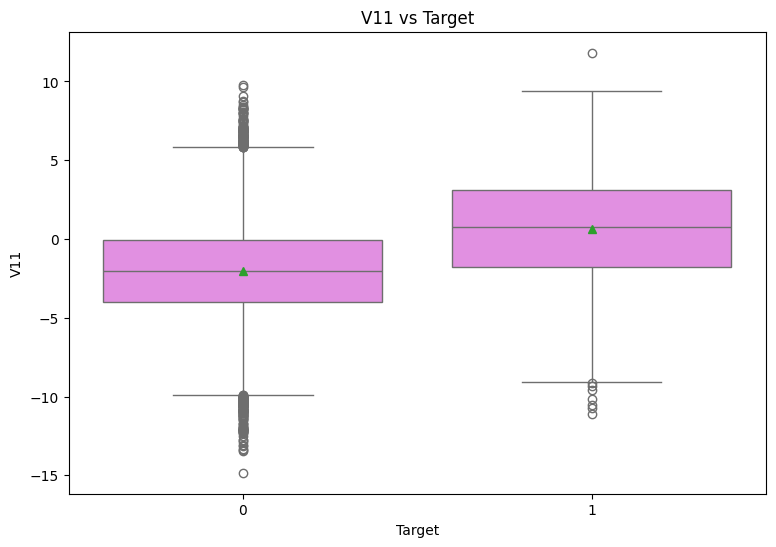

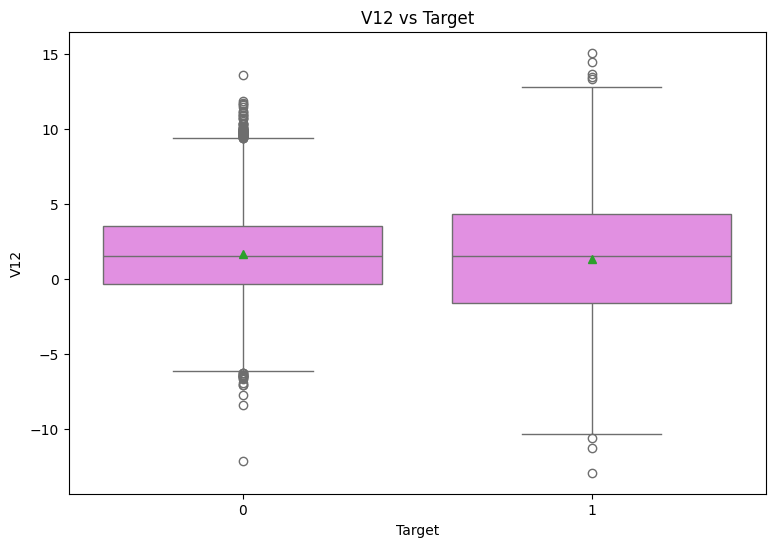

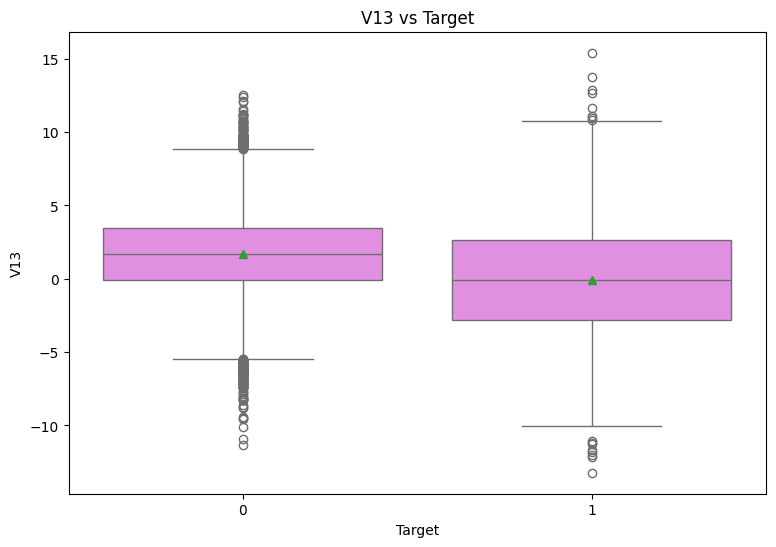

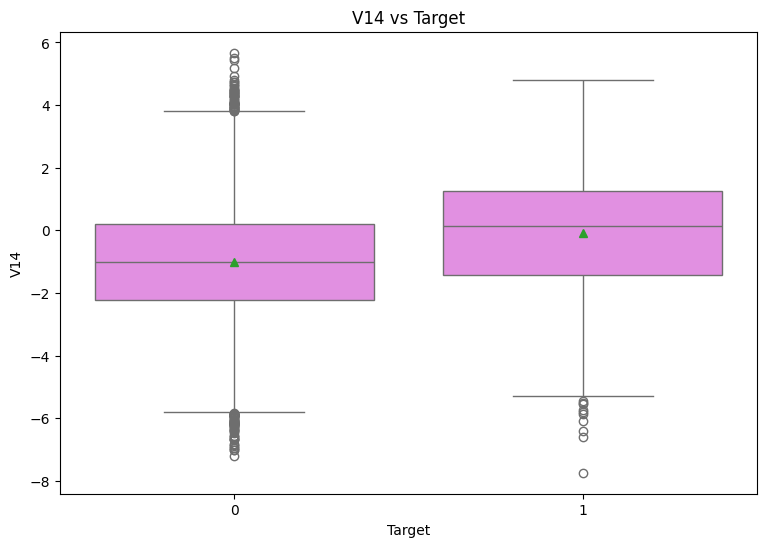

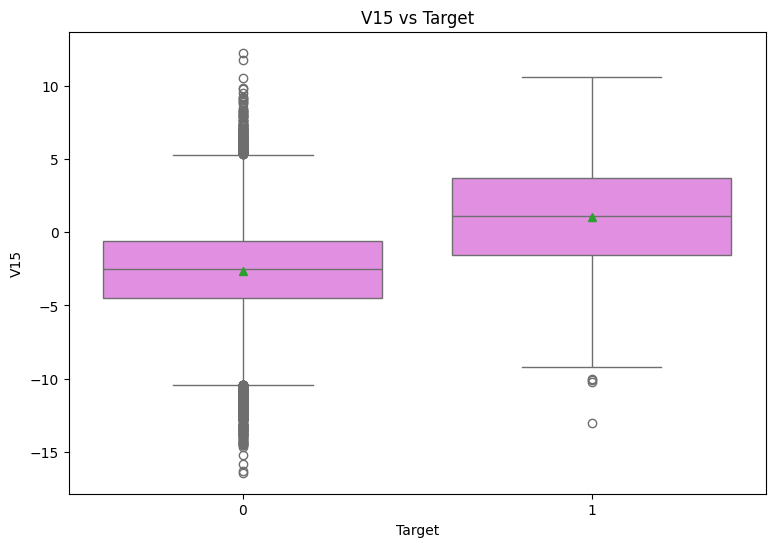

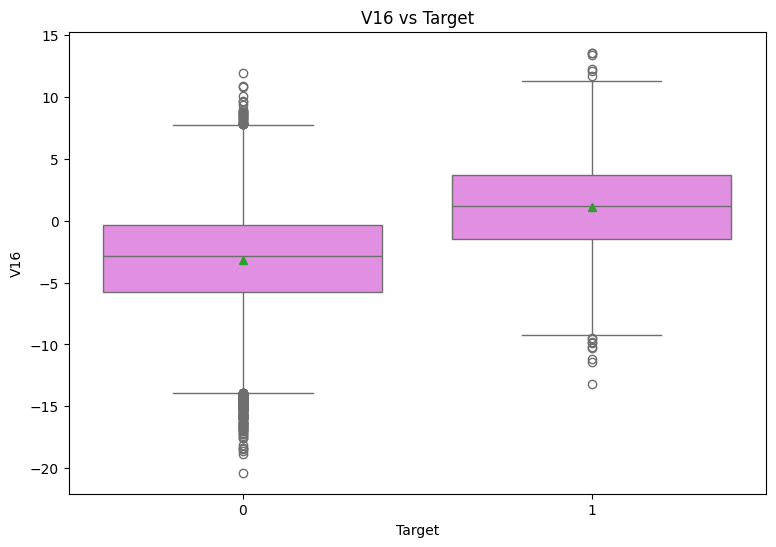

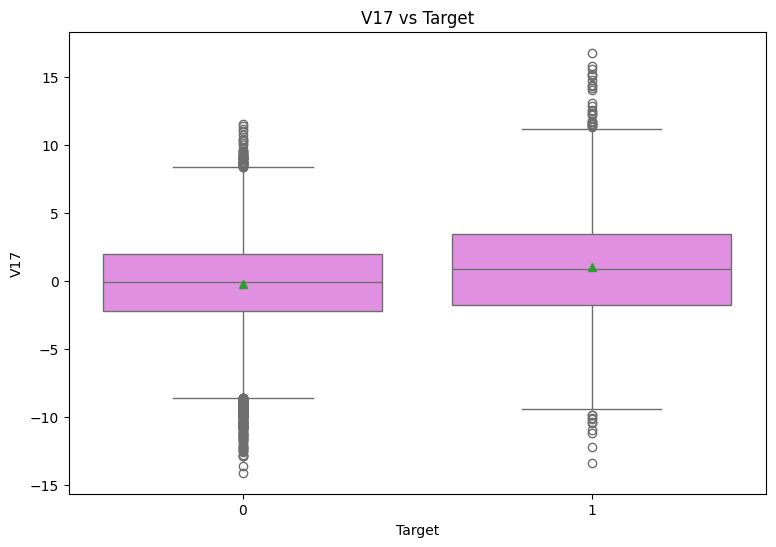

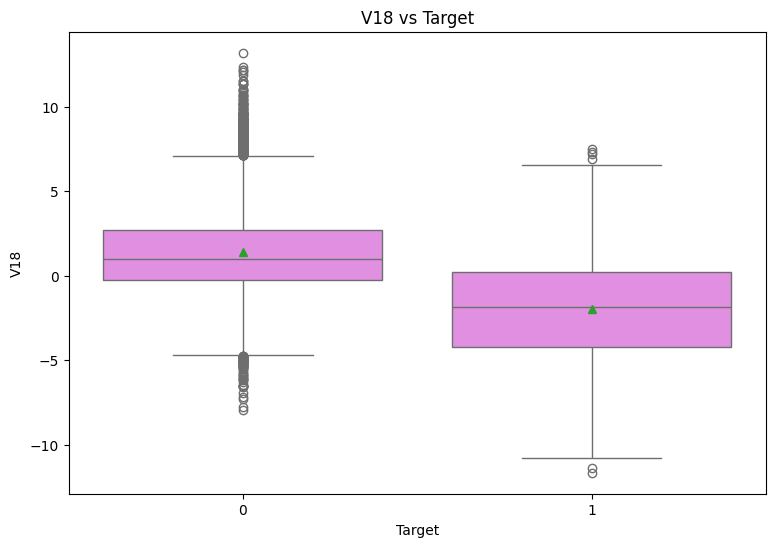

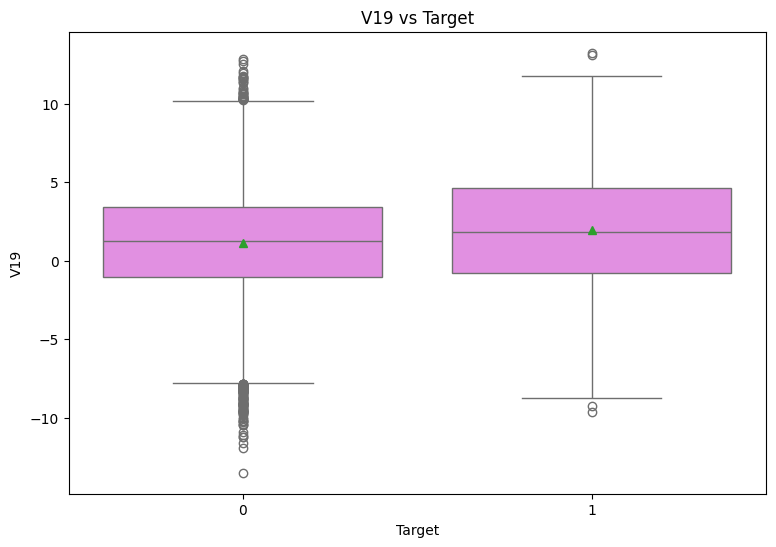

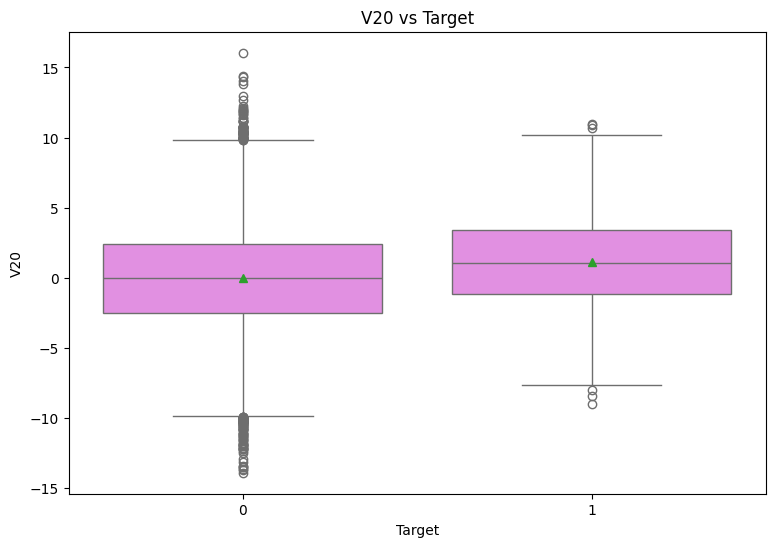

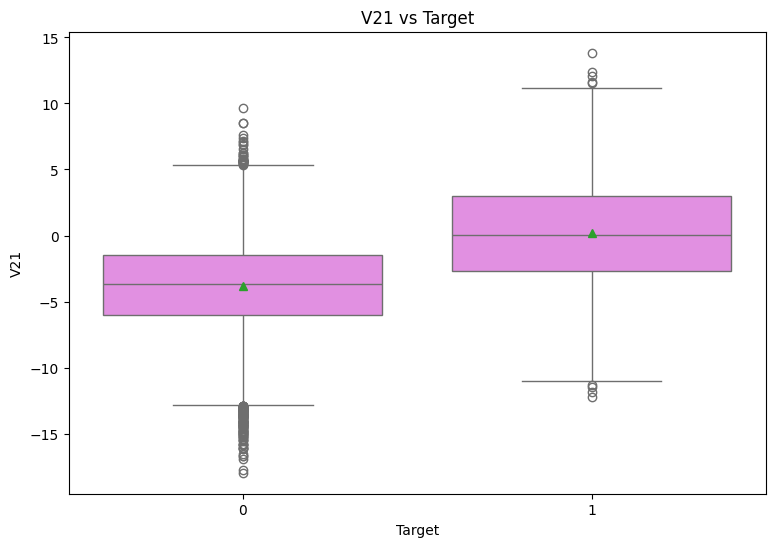

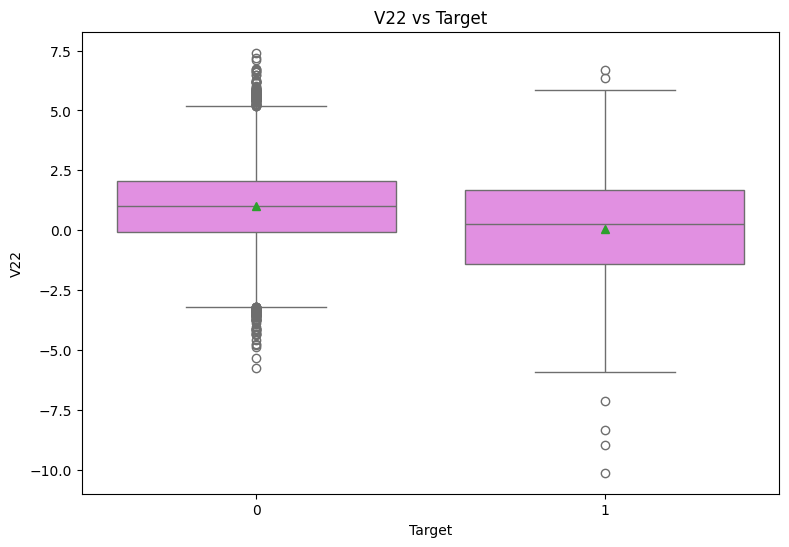

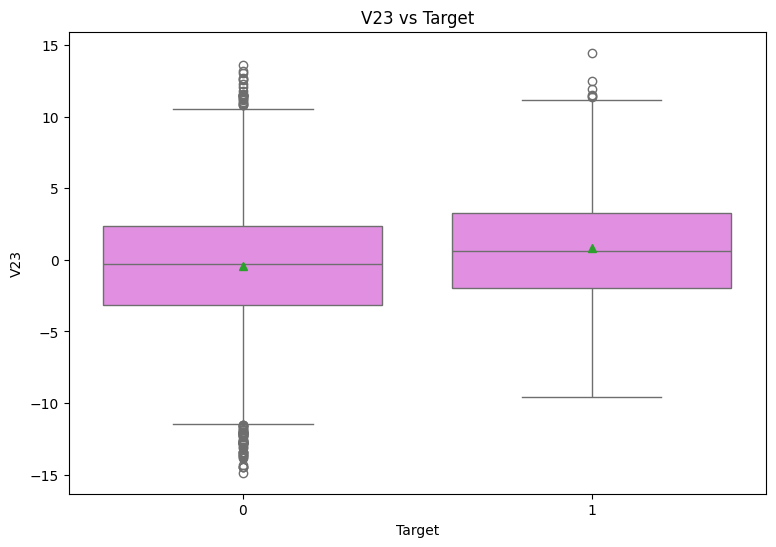

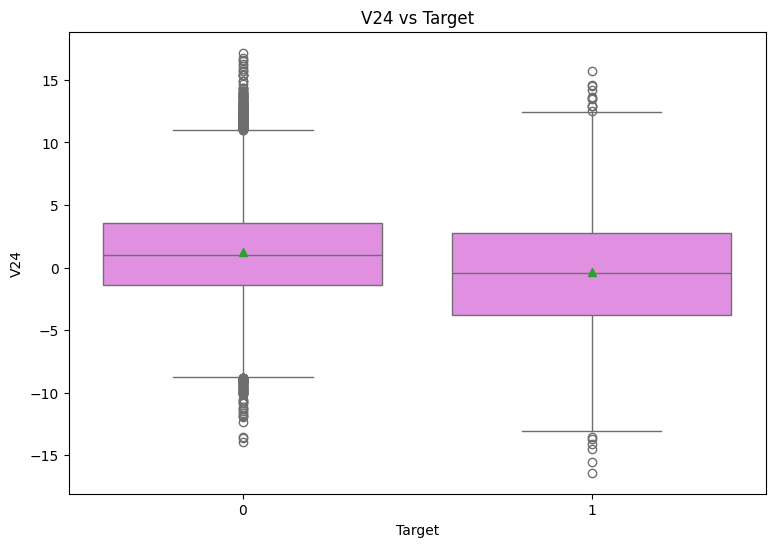

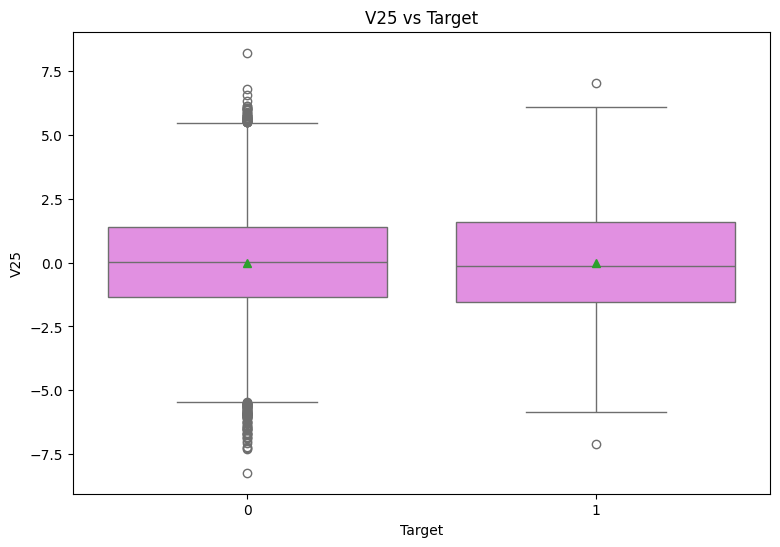

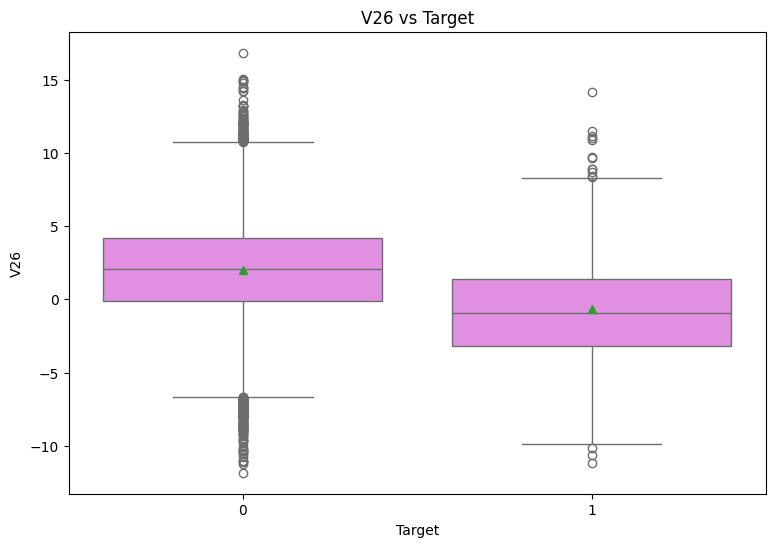

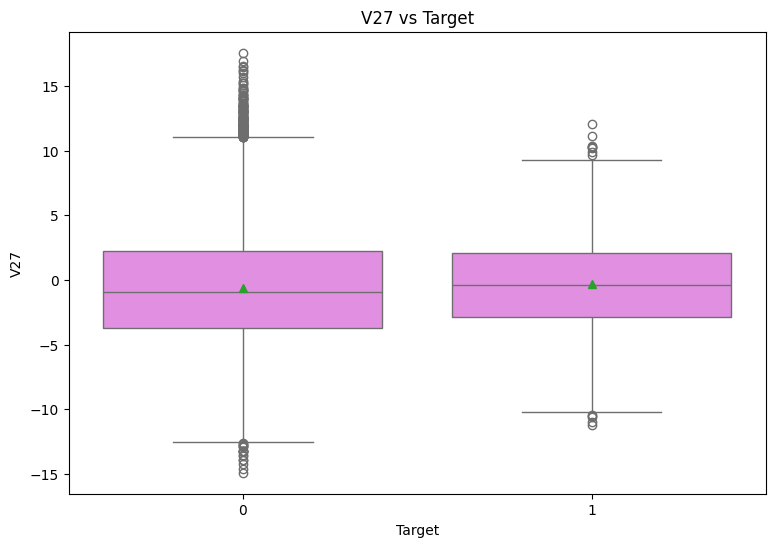

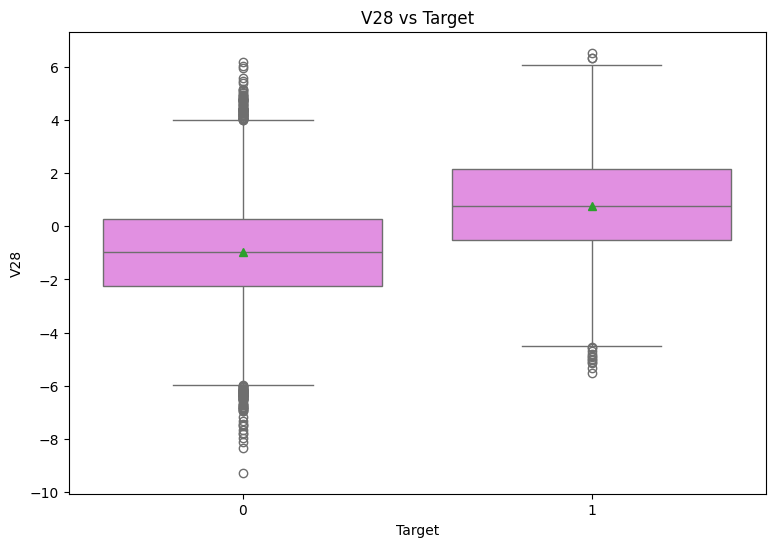

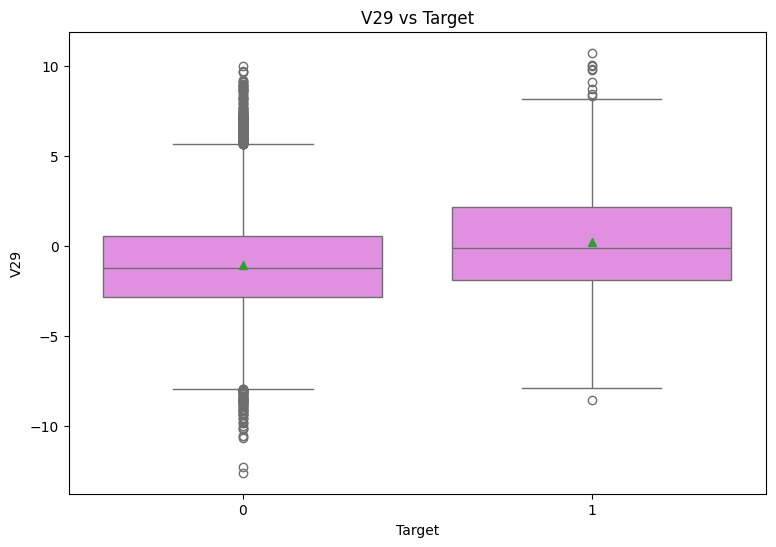

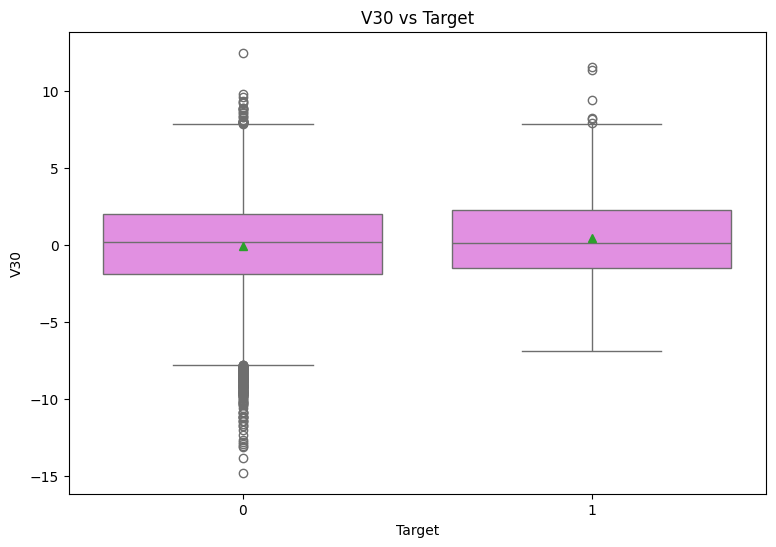

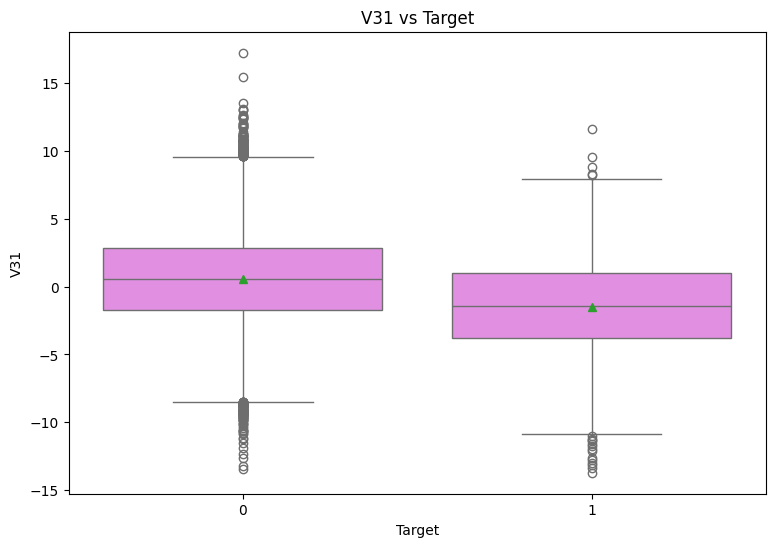

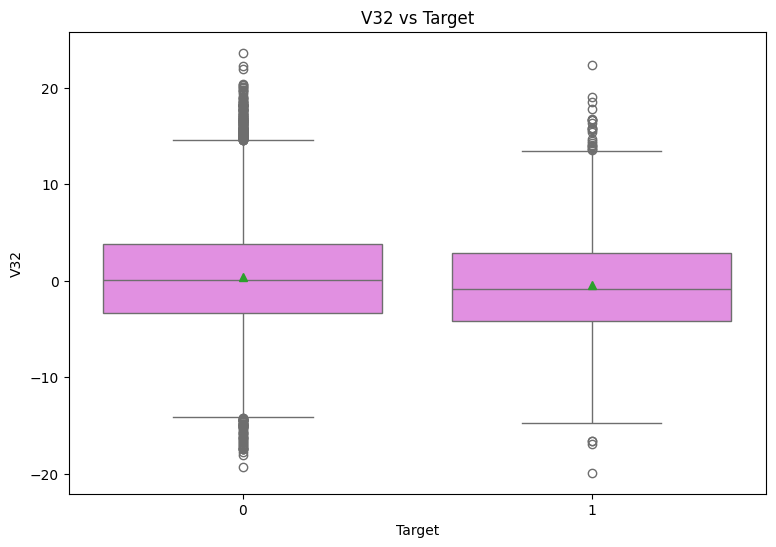

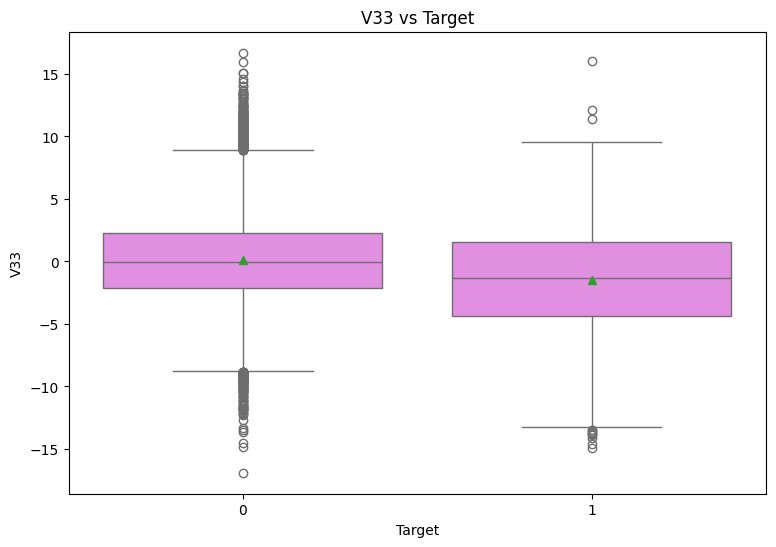

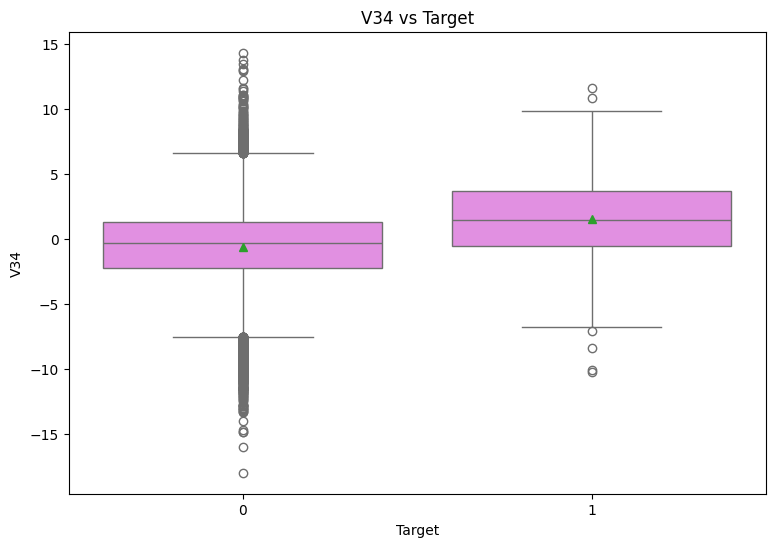

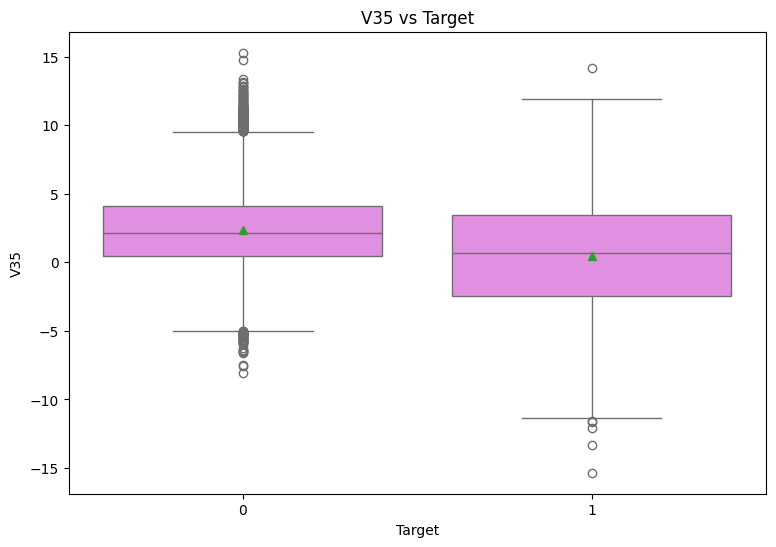

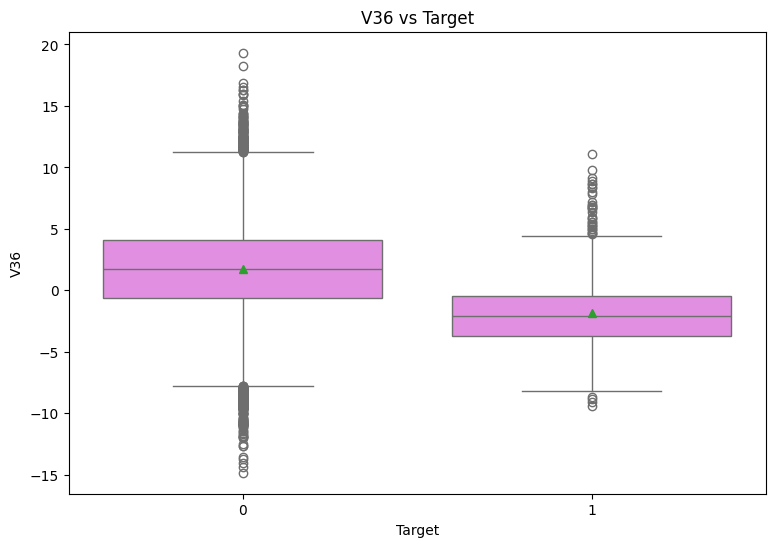

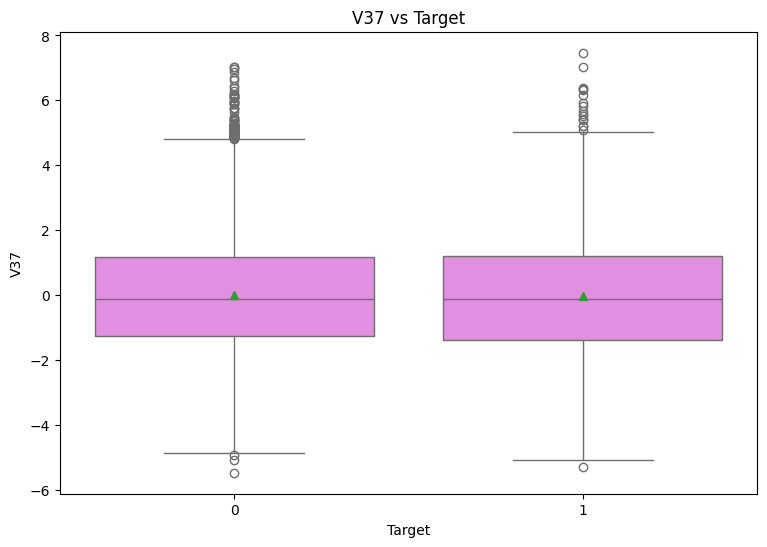

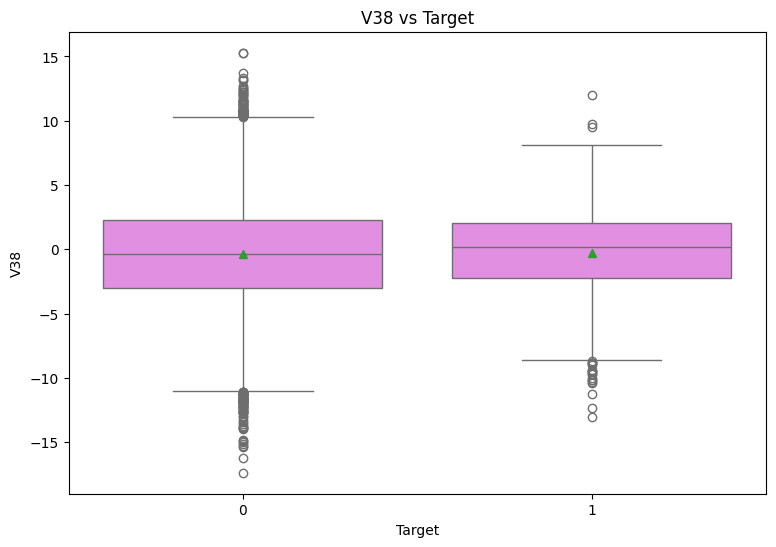

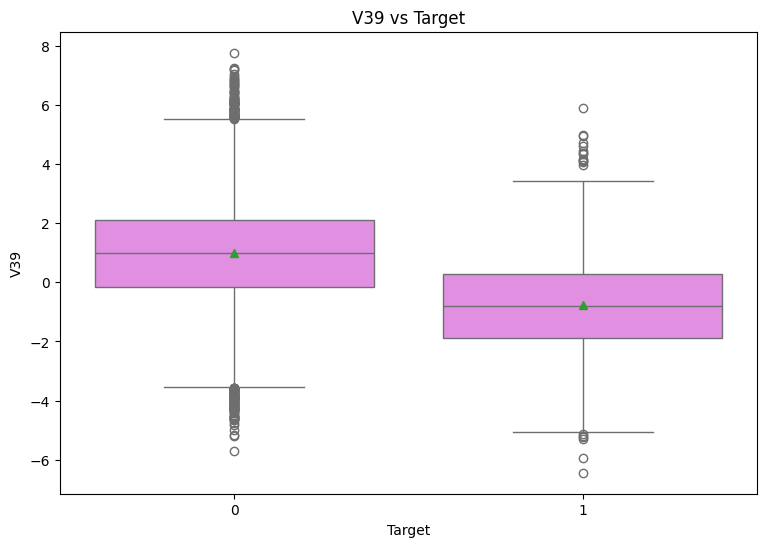

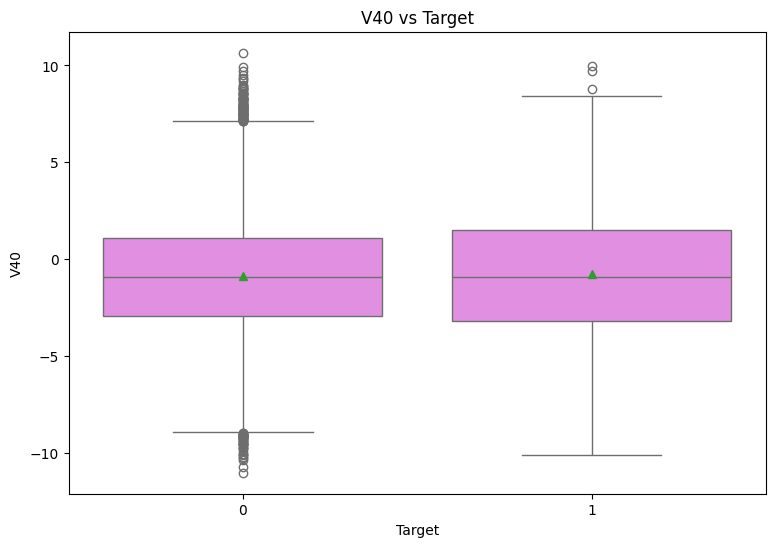

In [18]:
for col in independent_variables:
    plt.figure(figsize=(9, 6))
    sns.boxplot(data=data, x='Target', y=col, showmeans=True, color="violet")
    plt.title(f'{col} vs Target')
    plt.ylabel(col)
    plt.xlabel('Target')
    plt.show()

- Outliers are present in both the classes(1 and 0) for each feature.
- However, if we do the comparison, The Target class 1 has more outliers than the target class 0.

## Data Preprocessing

### Missing Value Imputation

As mentioned earlier, there are 18 records that has missing value for V1 and V2 columns. Hence, we will impute the missing values in the columns only using their median.

In [19]:
## Separating Independent and Dependent Columns
X = data.drop(['Target'],axis=1)
Y = data['Target']

In [20]:
# Create the imputer with median strategy
imputer = SimpleImputer(strategy='median')

# Fit and transform only on selected columns
X[['V1', 'V2']] = imputer.fit_transform(X[['V1', 'V2']])


In [21]:
X.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


### Splitting the dataset

In [22]:
# Splitting the dataset into the Training and validation set.
X_train, X_val, y_train, y_val = train_test_split(X,Y, test_size = 0.2, random_state = 42,stratify = Y)

In [23]:
#Printing the shapes.
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(16000, 40) (16000,)
(4000, 40) (4000,)


### Utility functions

In [24]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [25]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

In [26]:
def plot_confusion_matrix_and_print_classification_report(model, predictors, target):
    """
    To plot the confusion_matrix with percentages
    To print the classification report for class level matrics

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    for i in range(len(target)):
        if y_pred[i] > 0.5:
          y_pred[i] = 1
        else:
          y_pred[i] = 0

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    report = classification_report(target, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print(report_df)
    print("-" * 120)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")



## Model Building

### Model Evaluation Criteria

**A model can make wrong predictions in the following ways:**
* False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
* False positives (FP) are detections where there is no failure. These will result in inspection costs.

**Which case is more important?**

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

FN is actually important for the purposes of this case study. If our model predict that there is no failure in the generator but it get failed then Company has to beer the cost of replacement that is higher then the cost of repair and inspection.


**How to reduce this loss i.e need to reduce False Negatives ?**

Since FN errors are important for us to minimize, the company would want the recall Score evaluation metric to be maximized/ Hence, the focus should be on increasing the recall score.


As we are dealing with an imbalance in class distribution, we will be using class weights to allow the model to give proportionally more importance to the minority class.

In [27]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train)

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

In [28]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
epochs = 25
batch_size = 1024

### Model 1

- Let's start with a neural network consisting of
  - two hidden layers with 20 and 10 neurons respectively
  - activation function of ReLU.
  - SGD as the optimizer

In [29]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [30]:
#Initializing the neural network
model_1 = Sequential()
model_1.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model_1.add(Dense(10,activation="relu"))
model_1.add(Dense(1,activation="sigmoid"))

In [31]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,041 (4.07 KB)

 Trainable params: 1,041 (4.07 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used
model_1.compile(loss='binary_crossentropy', optimizer=optimizer)

In [33]:
start = time.time()
model_1_history = model_1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.7210 - val_loss: 0.8427
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7919 - val_loss: 0.6848
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6640 - val_loss: 0.6110
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5967 - val_loss: 0.5591
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5473 - val_loss: 0.5170
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5060 - val_loss: 0.4804
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4698 - val_loss: 0.4474
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4372 - val_loss: 0.4173
Epoch 9/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4076 - val_loss: 0.3898
Epoch 10/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3809 - val_loss: 0.3645
Epoch 11/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3567 - val_loss: 0.3420
Epoch 12/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3351 - val

In [34]:
print("Time taken in seconds ",end-start)

Time taken in seconds  6.022272348403931


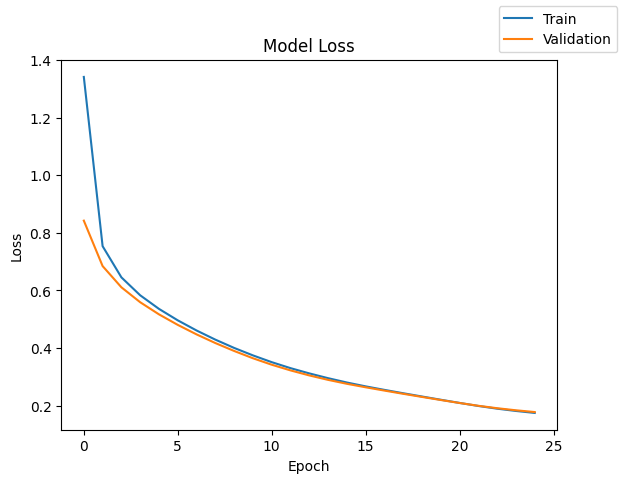

In [35]:
plot(model_1_history,'loss')

In [36]:
model_1_train_perf = model_performance_classification(model_1, X_train, y_train)
model_1_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.956688,0.956688,0.951422,0.946671


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score       support
0              0.959526  0.996162  0.977501  15112.000000
1              0.813505  0.284910  0.422018    888.000000
accuracy       0.956688  0.956688  0.956688      0.956688
macro avg      0.886515  0.640536  0.699760  16000.000000
weighted avg   0.951422  0.956688  0.946671  16000.000000
------------------------------------------------------------------------------------------------------------------------


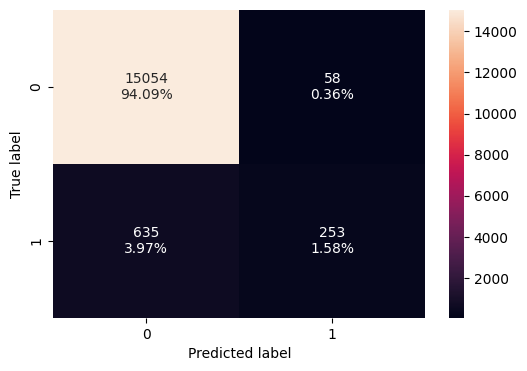

In [37]:
plot_confusion_matrix_and_print_classification_report(model_1, X_train, y_train)

In [38]:
model_1_val_perf = model_performance_classification(model_1, X_val, y_val)
model_1_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.95575,0.95575,0.951768,0.943863


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score     support
0              0.957328  0.997618  0.977058  3778.00000
1              0.857143  0.243243  0.378947   222.00000
accuracy       0.955750  0.955750  0.955750     0.95575
macro avg      0.907235  0.620431  0.678003  4000.00000
weighted avg   0.951768  0.955750  0.943863  4000.00000
------------------------------------------------------------------------------------------------------------------------


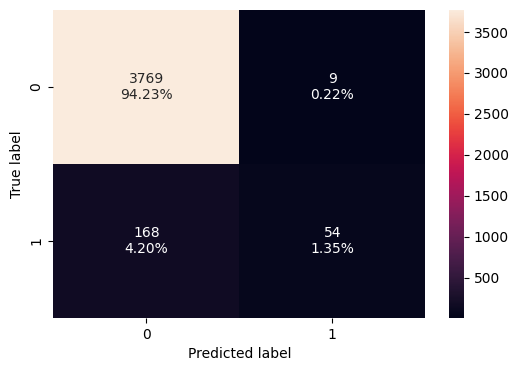

In [39]:
plot_confusion_matrix_and_print_classification_report(model_1, X_val, y_val)

- Train recall score of ~0.95 and validation recall score of ~0.95 indicate consistent performance of the model between training and validation datasets.

-  The model struggles to catch class 1 cases (low recall), even though predictions for class 1 are fairly precise.

- Consistent loss reduction: Training loss dropped from 1.7210 to 0.1776, and validation loss from 0.8427 to 0.1775.
- No overfitting: Validation loss closely tracks training loss, with no divergence.
- Smooth convergence: No abrupt spikes or plateaus — learning appears stable.
- The gap between training and validation curve is small and consistent, which suggests the model is generalizing well and not overfitting.
- Since model struggles to catch class 1 cases (low recall), so we need to look for other better models.



### Model 2

- Let's try adding momentum to check whether it's accelerating the learning process.

In [40]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [41]:
#Initializing the neural network
model_2 = Sequential()
model_2.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model_2.add(Dense(10,activation="relu"))
model_2.add(Dense(1,activation="sigmoid"))

In [42]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)    # defining SGD as the optimizer to be used
model_2.compile(loss='binary_crossentropy', optimizer=optimizer)

In [43]:
start = time.time()
model_2_history = model_2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.4788 - val_loss: 0.2064
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1777 - val_loss: 0.1452
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1329 - val_loss: 0.1285
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1186 - val_loss: 0.1167
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1087 - val_loss: 0.1096
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1020 - val_loss: 0.1040
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0969 - val_loss: 0.0994
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0927 - val_loss: 0.0956
Epoch 9/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0893 - val_loss: 0.0924
Epoch 10/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0863 - val_loss: 0.0896
Epoch 11/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0836 - val_loss: 0.0871
Epoch 12/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0813 - va

In [44]:
print("Time taken in seconds ",end-start)

Time taken in seconds  5.655229330062866


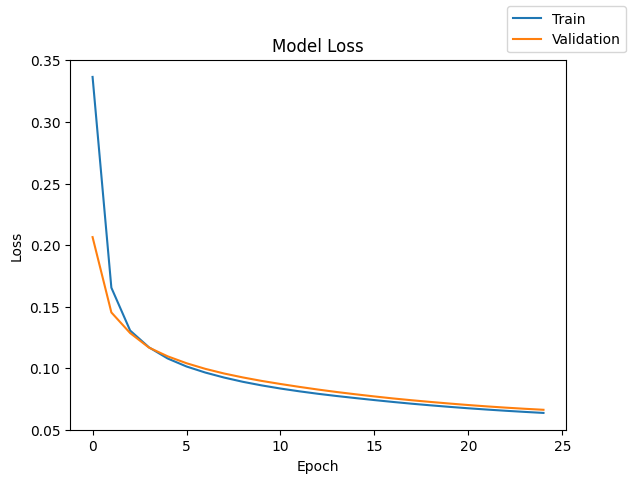

In [45]:
plot(model_2_history,'loss')

In [46]:
model_2_train_perf = model_performance_classification(model_2, X_train, y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.986437,0.986437,0.986256,0.985735


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score       support
0              0.987179  0.998610  0.992862  15112.000000
1              0.970547  0.779279  0.864460    888.000000
accuracy       0.986437  0.986437  0.986437      0.986437
macro avg      0.978863  0.888945  0.928661  16000.000000
weighted avg   0.986256  0.986437  0.985735  16000.000000
------------------------------------------------------------------------------------------------------------------------


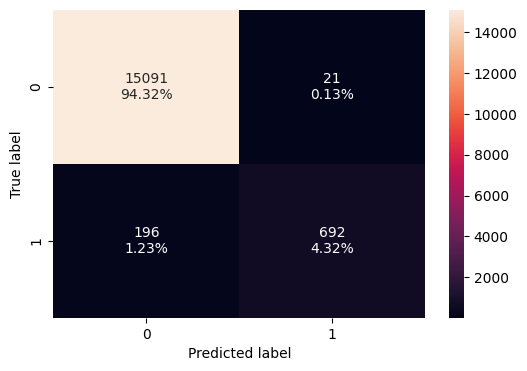

In [47]:
plot_confusion_matrix_and_print_classification_report(model_2, X_train, y_train)

In [48]:
model_2_val_perf = model_performance_classification(model_2, X_val, y_val)
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98575,0.98575,0.985519,0.984989


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score     support
0              0.986660  0.998412  0.992501  3778.00000
1              0.966102  0.770270  0.857143   222.00000
accuracy       0.985750  0.985750  0.985750     0.98575
macro avg      0.976381  0.884341  0.924822  4000.00000
weighted avg   0.985519  0.985750  0.984989  4000.00000
------------------------------------------------------------------------------------------------------------------------


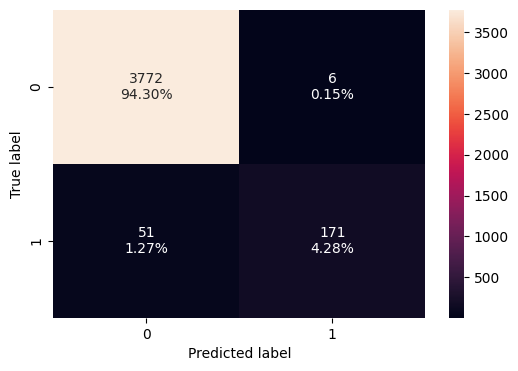

In [49]:
plot_confusion_matrix_and_print_classification_report(model_2, X_val, y_val)

- Train recall score of ~0.98 and validation recall score of ~0.98 indicate consistent performance of the model between training and validation datasets.

- The recall of this model increase as compare to previous model.

-  As compared to previous model, this model is capable to catch class 1 cases (~0.77) more.

- Consistent loss reduction: Training loss dropped from 0.47 to 0.06, and validation loss from 0.20 to 0.06.
- No overfitting: Validation loss closely tracks training loss, with no divergence.
- Smooth convergence: No abrupt spikes or plateaus — learning appears stable.
- The gap between training and validation curve is small and consistent, which suggests the model is generalizing well and not overfitting.



### Model 3

In [50]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [51]:
#Initializing the neural network
model_3 = Sequential()
model_3.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model_3.add(Dense(10,activation="relu"))
model_3.add(Dense(1,activation="sigmoid"))

In [52]:
optimizer = tf.keras.optimizers.Adam()   # defining Adam as the optimizer to be used
model_3.compile(loss='binary_crossentropy', optimizer=optimizer)

In [53]:
start = time.time()
model_3_history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight = cw_dict)
end=time.time()

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 3.9393 - val_loss: 1.5450
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9542 - val_loss: 0.7107
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1834 - val_loss: 0.5454
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9064 - val_loss: 0.4506
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7895 - val_loss: 0.3810
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7186 - val_loss: 0.3484
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6716 - val_loss: 0.3246
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6357 - val_loss: 0.3028
Epoch 9/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6070 - val_loss: 0.2858
Epoch 10/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5833 - val_loss: 0.2720
Epoch 11/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5640 - val_loss: 0.2600
Epoch 12/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5477 - val_l

In [54]:
print("Time taken in seconds ",end-start)

Time taken in seconds  5.81329607963562


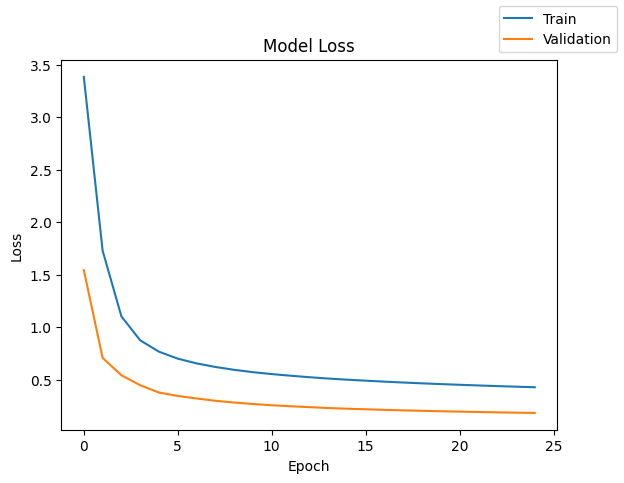

In [55]:
plot(model_3_history,'loss')

In [56]:
model_3_train_perf = model_performance_classification(model_3, X_train, y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.959375,0.959375,0.971308,0.963305


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score       support
0              0.993853  0.962943  0.978154  15112.000000
1              0.587629  0.898649  0.710597    888.000000
accuracy       0.959375  0.959375  0.959375      0.959375
macro avg      0.790741  0.930796  0.844375  16000.000000
weighted avg   0.971308  0.959375  0.963305  16000.000000
------------------------------------------------------------------------------------------------------------------------


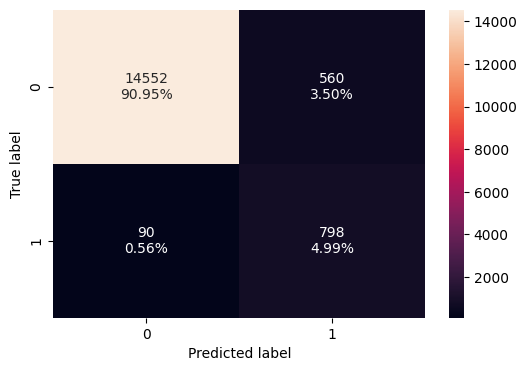

In [57]:
plot_confusion_matrix_and_print_classification_report(model_3, X_train, y_train)

In [58]:
model_3_val_perf = model_performance_classification(model_3, X_val, y_val)
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.95925,0.95925,0.971827,0.963333


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score     support
0              0.994528  0.962149  0.978071  3778.00000
1              0.585507  0.909910  0.712522   222.00000
accuracy       0.959250  0.959250  0.959250     0.95925
macro avg      0.790018  0.936030  0.845296  4000.00000
weighted avg   0.971827  0.959250  0.963333  4000.00000
------------------------------------------------------------------------------------------------------------------------


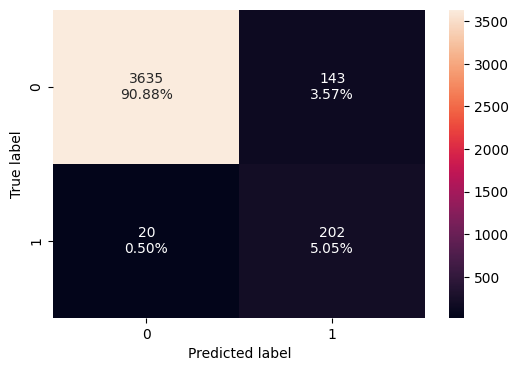

In [59]:
plot_confusion_matrix_and_print_classification_report(model_3, X_val, y_val)

- Train recall score of ~0.95 and validation recall score of ~0.95 indicate consistent performance of the model between training and validation datasets.

- The recall of this model is less than the previous model. However, this model is capable to catch class 1 cases (~0.89) more than the previous one.

- Consistent loss reduction: Training loss dropped from 0.95 to 0.89, and validation loss from 0.95 to 0.90.
- No overfitting: Validation loss closely tracks training loss, with no divergence.
- Smooth convergence: No abrupt spikes or plateaus — learning appears stable.
- As compared to previous two models, The gap between training and validation curve is larger, but consistent, which suggests the model is generalizing well and not overfitting.



### Model 4

In [60]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [61]:
#Initializing the neural network
model_4 = Sequential()
model_4.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model_4.add(Dropout(0.4))
model_4.add(Dense(10,activation="relu"))
model_4.add(Dropout(0.2))
model_4.add(Dense(1,activation="sigmoid"))

In [62]:
optimizer = tf.keras.optimizers.Adam()   # defining Adam as the optimizer to be used
model_4.compile(loss='binary_crossentropy', optimizer=optimizer)

In [63]:
start = time.time()
model_4_history = model_4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight = cw_dict)
end=time.time()

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 2.2002 - val_loss: 0.4983
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7172 - val_loss: 0.4465
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4633 - val_loss: 0.4371
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.2602 - val_loss: 0.4227
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1587 - val_loss: 0.4154
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0981 - val_loss: 0.4077
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9783 - val_loss: 0.3820
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9730 - val_loss: 0.3697
Epoch 9/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8923 - val_loss: 0.3581
Epoch 10/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8705 - val_loss: 0.3546
Epoch 11/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8701 - val_loss: 0.3492
Epoch 12/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8115 

In [64]:
print("Time taken in seconds ",end-start)

Time taken in seconds  7.985735654830933


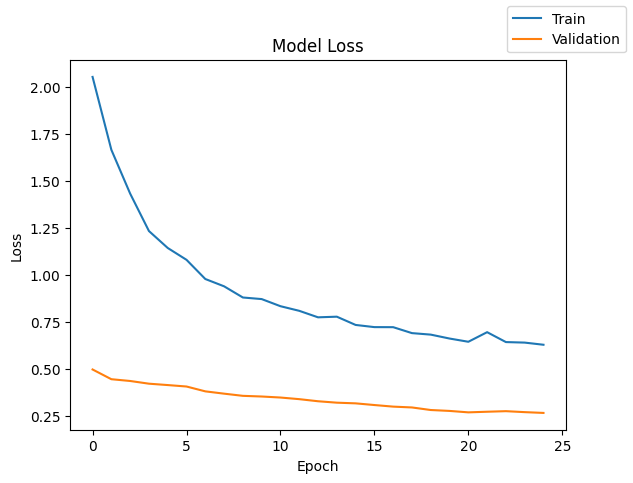

In [65]:
plot(model_4_history,'loss')

In [66]:
model_4_train_perf = model_performance_classification(model_4, X_train, y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.956625,0.956625,0.96951,0.960944


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score       support
0              0.992957  0.960892  0.976661  15112.000000
1              0.570494  0.884009  0.693463    888.000000
accuracy       0.956625  0.956625  0.956625      0.956625
macro avg      0.781725  0.922451  0.835062  16000.000000
weighted avg   0.969510  0.956625  0.960944  16000.000000
------------------------------------------------------------------------------------------------------------------------


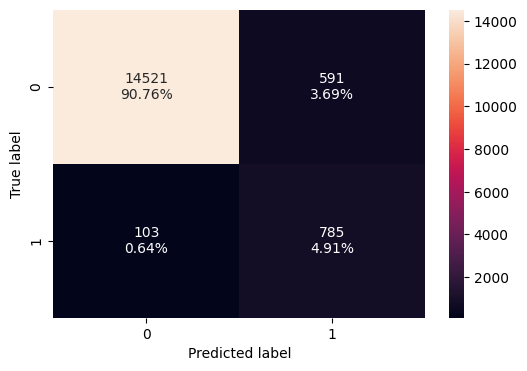

In [67]:
plot_confusion_matrix_and_print_classification_report(model_4, X_train, y_train)

In [68]:
model_4_val_perf = model_performance_classification(model_4, X_val, y_val)
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.956,0.956,0.970629,0.960755


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support
0              0.994509  0.958708  0.976280  3778.000
1              0.564246  0.909910  0.696552   222.000
accuracy       0.956000  0.956000  0.956000     0.956
macro avg      0.779377  0.934309  0.836416  4000.000
weighted avg   0.970629  0.956000  0.960755  4000.000
------------------------------------------------------------------------------------------------------------------------


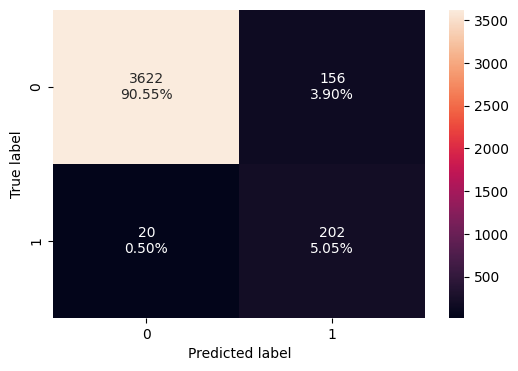

In [69]:
plot_confusion_matrix_and_print_classification_report(model_4, X_val, y_val)

- Train recall score of ~0.95 and validation recall score of ~0.95 indicate consistent performance of the model between training and validation datasets.

- The recall of this model is same as the previous model.

- The model is capable to catch class 1 cases (~0.89) same as the previous one. But this model catches class 1 cases in validation set more than the training set.

- Consistent loss reduction: Training loss dropped from 0.95 to 0.88, and validation loss from 0.95 to 0.90.
- No overfitting: Validation loss closely tracks training loss, with no divergence.
- Smooth convergence: No abrupt spikes or plateaus — learning appears stable.
- As compared to previous models, The gap between training and validation curve is larger, but consistent, which suggests the model is generalizing well and not overfitting.



### Model 5

In [70]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [71]:
#Initializing the neural network
model_5 = Sequential()
model_5.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model_5.add(Dense(10,activation="relu"))
model_5.add(Dense(5,activation="relu"))
model_5.add(Dense(1,activation="sigmoid"))

In [72]:
optimizer = tf.keras.optimizers.Adam()   # defining Adam as the optimizer to be used
model_5.compile(loss='binary_crossentropy', optimizer=optimizer)

In [73]:
start = time.time()
model_5_history = model_5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight = cw_dict)
end=time.time()

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.8340 - val_loss: 0.9753
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3102 - val_loss: 0.8110
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1767 - val_loss: 0.7642
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1029 - val_loss: 0.7429
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0476 - val_loss: 0.7264
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0029 - val_loss: 0.7087
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9643 - val_loss: 0.6905
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9295 - val_loss: 0.6753
Epoch 9/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8986 - val_loss: 0.6626
Epoch 10/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8699 - val_loss: 0.6480
Epoch 11/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8440 - val_loss: 0.6337
Epoch 12/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8216 - va

In [74]:
print("Time taken in seconds ",end-start)

Time taken in seconds  6.717588663101196


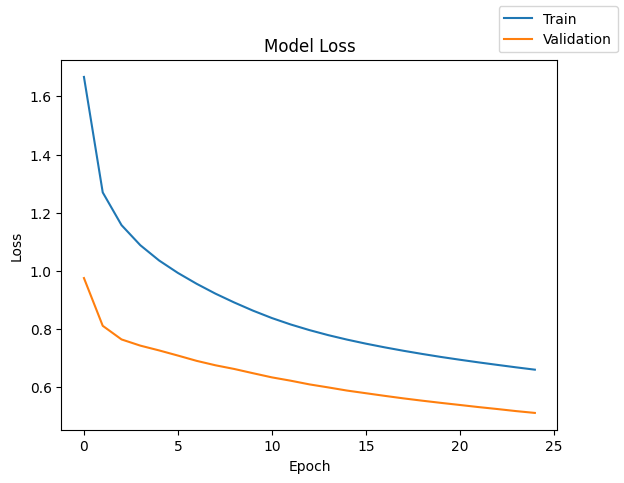

In [75]:
plot(model_5_history,'loss')

In [76]:
model_5_train_perf = model_performance_classification(model_5, X_train, y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.969,0.969,0.975781,0.971235


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score    support
0              0.994251  0.972803  0.983410  15112.000
1              0.661450  0.904279  0.764034    888.000
accuracy       0.969000  0.969000  0.969000      0.969
macro avg      0.827851  0.938541  0.873722  16000.000
weighted avg   0.975781  0.969000  0.971235  16000.000
------------------------------------------------------------------------------------------------------------------------


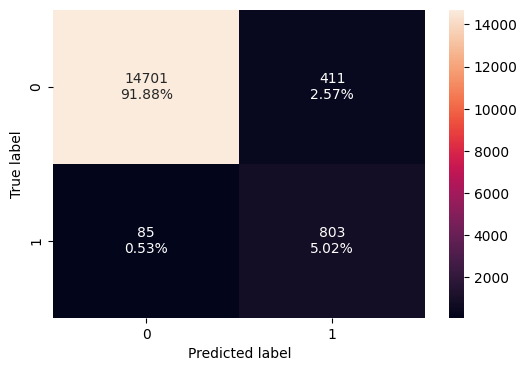

In [77]:
plot_confusion_matrix_and_print_classification_report(model_5, X_train, y_train)

In [78]:
model_5_val_perf = model_performance_classification(model_5, X_val, y_val)
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.97125,0.97125,0.977146,0.973183


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score     support
0              0.994599  0.974854  0.984628  3778.00000
1              0.680135  0.909910  0.778420   222.00000
accuracy       0.971250  0.971250  0.971250     0.97125
macro avg      0.837367  0.942382  0.881524  4000.00000
weighted avg   0.977146  0.971250  0.973183  4000.00000
------------------------------------------------------------------------------------------------------------------------


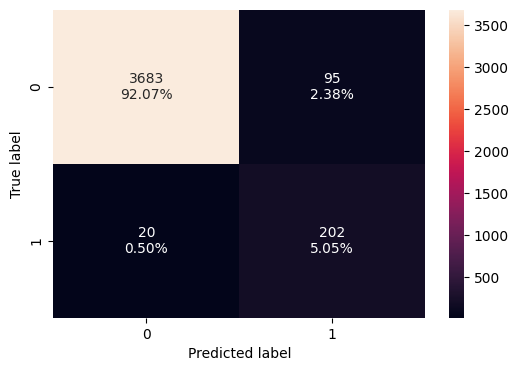

In [79]:
plot_confusion_matrix_and_print_classification_report(model_5, X_val, y_val)

- Train recall score of ~0.96 and validation recall score of ~0.97 indicate  performance of the model on validation datasets is better than on training dataset.

- The recall of this model is higher than the previous models.

- The model is capable to catch class 1 cases (~0.90) same on validation datasets and training dataset.

- Consistent loss reduction: Training loss dropped from 1.83 to 0.65, and validation loss from 0.97 to 0.51.

- No overfitting: Validation loss closely tracks training loss, with no divergence.
- Smooth convergence: No abrupt spikes or plateaus — learning appears stable.
- This model works well on validation dataset than training dataset.



### Model 6

In [80]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [81]:
#Initializing the neural network
model_6 = Sequential()
model_6.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model_6.add(Dense(10,activation="relu"))
model_6.add(Dense(5,activation="relu"))
model_6.add(Dense(1,activation="sigmoid"))

In [82]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)   # defining Adam as the optimizer to be used
model_6.compile(loss='binary_crossentropy', optimizer=optimizer)

In [83]:
start = time.time()
model_6_history = model_6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight = cw_dict)
end=time.time()

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.3425 - val_loss: 0.2898
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9713 - val_loss: 0.2595
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7093 - val_loss: 0.2040
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5938 - val_loss: 0.2103
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5400 - val_loss: 0.1869
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4979 - val_loss: 0.1569
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4682 - val_loss: 0.1461
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4475 - val_loss: 0.1354
Epoch 9/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4313 - val_loss: 0.1261
Epoch 10/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4183 - val_loss: 0.1168
Epoch 11/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4091 - val_loss: 0.1112
Epoch 12/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4003 - val_

In [84]:
print("Time taken in seconds ",end-start)

Time taken in seconds  4.9482810497283936


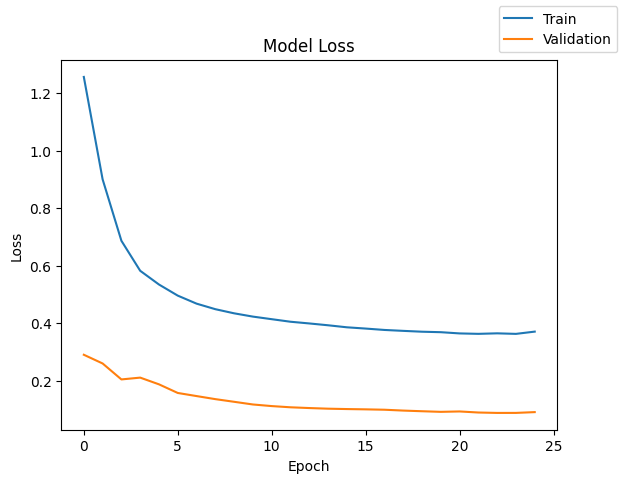

In [85]:
plot(model_6_history,'loss')

In [86]:
model_6_train_perf = model_performance_classification(model_6, X_train, y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.984313,0.984313,0.984848,0.984534


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score       support
0              0.993491  0.989876  0.991680  15112.000000
1              0.837752  0.889640  0.862916    888.000000
accuracy       0.984313  0.984313  0.984313      0.984313
macro avg      0.915622  0.939758  0.927298  16000.000000
weighted avg   0.984848  0.984313  0.984534  16000.000000
------------------------------------------------------------------------------------------------------------------------


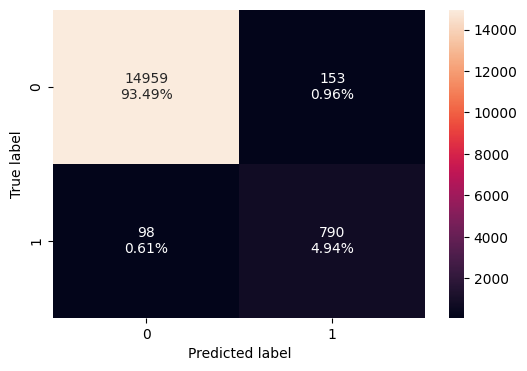

In [87]:
plot_confusion_matrix_and_print_classification_report(model_6, X_train, y_train)

In [88]:
model_6_val_perf = model_performance_classification(model_6, X_val, y_val)
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98325,0.98325,0.984168,0.983605


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score     support
0              0.993878  0.988354  0.991108  3778.00000
1              0.818930  0.896396  0.855914   222.00000
accuracy       0.983250  0.983250  0.983250     0.98325
macro avg      0.906404  0.942375  0.923511  4000.00000
weighted avg   0.984168  0.983250  0.983605  4000.00000
------------------------------------------------------------------------------------------------------------------------


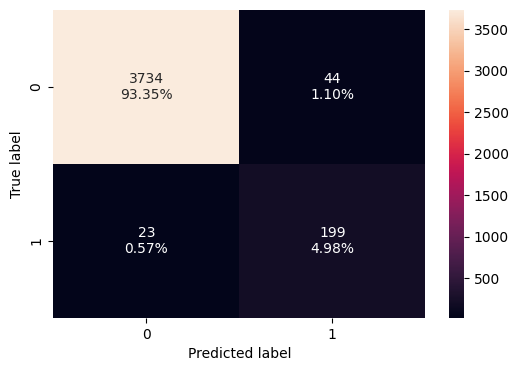

In [89]:
plot_confusion_matrix_and_print_classification_report(model_6, X_val, y_val)

- Train recall score of ~0.98 and validation recall score of ~0.98 indicate consisitent performance of the model on validation datasets as well as on training dataset.

- The recall of this model is higher than the previous models.

- The model is capable to catch class 1 cases (~0.89) on validation datasets that is more than on training dataset.

- Consistent loss reduction: Training loss dropped from 0.98 to 0.88, and validation loss from 0.98 to 0.89.

- No overfitting: Validation loss closely tracks training loss, with no divergence.
- Smooth convergence: No abrupt spikes or plateaus — learning appears stable.
- This model works well on validation dataset than training dataset.



### Model 7

In [90]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [91]:
#Initializing the neural network
model_7 = Sequential()
model_7.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model_7.add(Dense(10,activation="relu"))
model_7.add(Dense(5,activation="relu"))
model_7.add(Dense(1,activation="sigmoid"))

In [92]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9, learning_rate=0.0001)   # defining Adam as the optimizer to be used
model_7.compile(loss='binary_crossentropy', optimizer=optimizer)

In [93]:
start = time.time()
model_7_history = model_7.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight = cw_dict)
end=time.time()

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.5041 - val_loss: 0.6397
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4587 - val_loss: 0.6060
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4051 - val_loss: 0.5773
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3582 - val_loss: 0.5544
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3186 - val_loss: 0.5357
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2846 - val_loss: 0.5199
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2545 - val_loss: 0.5065
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2280 - val_loss: 0.4947
Epoch 9/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2045 - val_loss: 0.4841
Epoch 10/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1827 - val_loss: 0.4745
Epoch 11/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1625 - val_loss: 0.4659
Epoch 12/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1441 - val_l

In [94]:
print("Time taken in seconds ",end-start)

Time taken in seconds  4.890255451202393


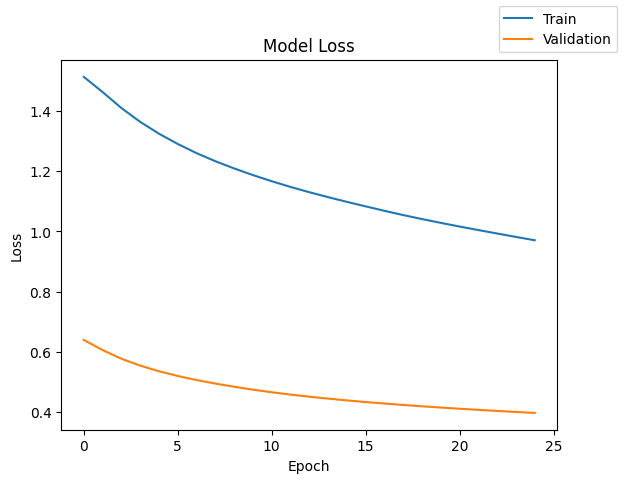

In [95]:
plot(model_7_history,'loss')

In [96]:
model_7_train_perf = model_performance_classification(model_7, X_train, y_train)
model_7_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.848938,0.848938,0.943699,0.883779


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score       support
0              0.985172  0.852898  0.914276  15112.000000
1              0.237916  0.781532  0.364783    888.000000
accuracy       0.848938  0.848938  0.848938      0.848938
macro avg      0.611544  0.817215  0.639529  16000.000000
weighted avg   0.943699  0.848938  0.883779  16000.000000
------------------------------------------------------------------------------------------------------------------------


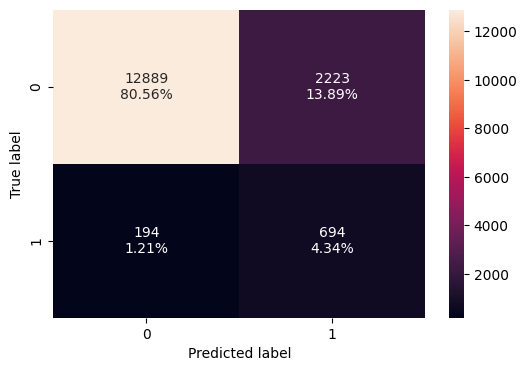

In [97]:
plot_confusion_matrix_and_print_classification_report(model_7, X_train, y_train)

In [98]:
model_7_val_perf = model_performance_classification(model_7, X_val, y_val)
model_7_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.8515,0.8515,0.947611,0.886064


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score    support
0              0.988643  0.852567  0.915577  3778.0000
1              0.249326  0.833333  0.383817   222.0000
accuracy       0.851500  0.851500  0.851500     0.8515
macro avg      0.618985  0.842950  0.649697  4000.0000
weighted avg   0.947611  0.851500  0.886064  4000.0000
------------------------------------------------------------------------------------------------------------------------


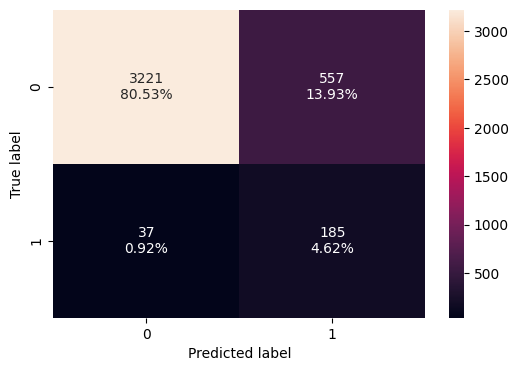

In [99]:
plot_confusion_matrix_and_print_classification_report(model_7, X_val, y_val)

- Train recall score of ~0.84 and validation recall score of ~0.85 indicate  performance of the model on validation datasets is better than on training dataset.

- The recall of this model is worse than all the previous models.



### Model 8

In [100]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [101]:
#adding earlystopping callback
es= keras.callbacks.EarlyStopping(monitor='val_loss',
                              min_delta=0,
                              patience=15,
                             verbose=0, mode='min', restore_best_weights= True)

In [102]:
#Initializing the neural network
model_8 = Sequential()
model_8.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model_8.add(Dense(10,activation="relu"))
model_8.add(Dense(5,activation="relu"))
model_8.add(Dense(1,activation="sigmoid"))

In [103]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)   # defining Adam as the optimizer to be used
model_8.compile(loss='binary_crossentropy', optimizer=optimizer)

In [104]:
start = time.time()
model_8_history = model_8.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight = cw_dict, callbacks=[es])
end=time.time()

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.8085 - val_loss: 0.5553
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8497 - val_loss: 0.3649
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7192 - val_loss: 0.3094
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6254 - val_loss: 0.2594
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5726 - val_loss: 0.2450
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5301 - val_loss: 0.2129
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4929 - val_loss: 0.1991
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4613 - val_loss: 0.1776
Epoch 9/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4366 - val_loss: 0.1706
Epoch 10/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4146 - val_loss: 0.1606
Epoch 11/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3952 - val_loss: 0.1675
Epoch 12/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3798 - 

In [105]:
print("Time taken in seconds ",end-start)

Time taken in seconds  6.0535266399383545


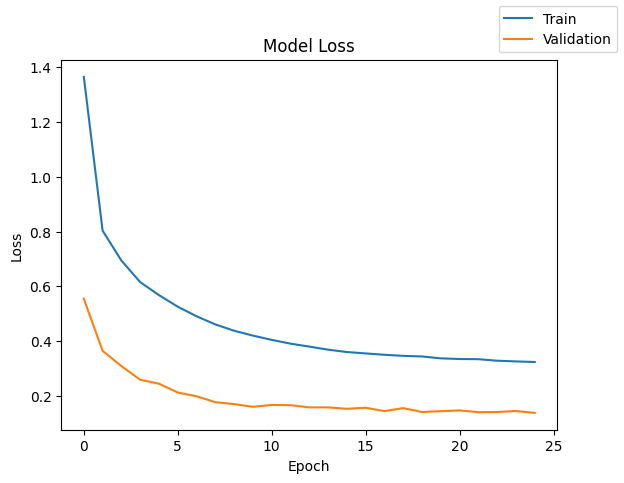

In [106]:
plot(model_8_history,'loss')

In [107]:
model_8_train_perf = model_performance_classification(model_8, X_train, y_train)
model_8_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.980125,0.980125,0.982488,0.980928


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score       support
0              0.994981  0.983920  0.989420  15112.000000
1              0.769886  0.915541  0.836420    888.000000
accuracy       0.980125  0.980125  0.980125      0.980125
macro avg      0.882434  0.949730  0.912920  16000.000000
weighted avg   0.982488  0.980125  0.980928  16000.000000
------------------------------------------------------------------------------------------------------------------------


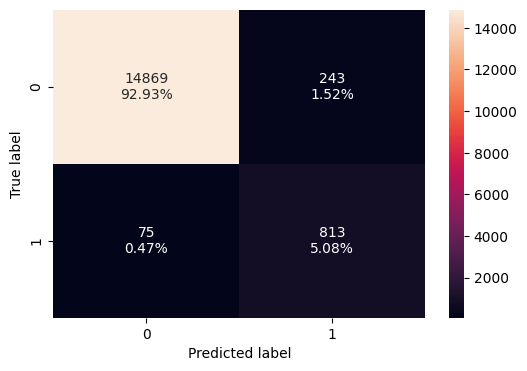

In [108]:
plot_confusion_matrix_and_print_classification_report(model_8, X_train, y_train)

In [109]:
model_8_val_perf = model_performance_classification(model_8, X_val, y_val)
model_8_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.97625,0.97625,0.979899,0.977472


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score     support
0              0.994628  0.980148  0.987335  3778.00000
1              0.729242  0.909910  0.809619   222.00000
accuracy       0.976250  0.976250  0.976250     0.97625
macro avg      0.861935  0.945029  0.898477  4000.00000
weighted avg   0.979899  0.976250  0.977472  4000.00000
------------------------------------------------------------------------------------------------------------------------


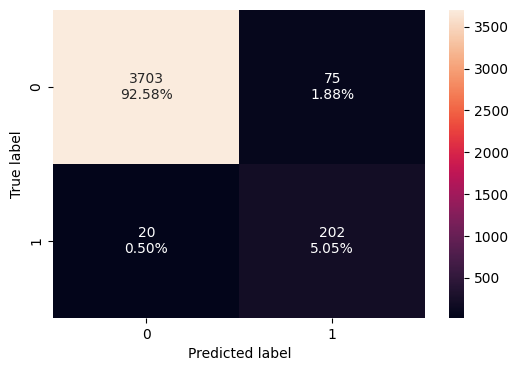

In [110]:
plot_confusion_matrix_and_print_classification_report(model_8, X_val, y_val)

- Train recall score of ~0.98 and validation recall score of ~0.97 indicate consistent performance of the model

- The recall of this model is higher than the previous model.

- The model is capable to catch class 1 cases (~0.90) more on train datasets than training dataset.

- Consistent loss reduction: Training loss dropped from 1.80 to 0.31, and validation loss from 0.55 to 0.13.

- No overfitting: Validation loss closely tracks training loss, with no divergence.



## Model Performance Comparison and Final Model Selection

In [111]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T,
        model_7_train_perf.T,
        model_8_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Neural Network (SGD, 2 hidden layer, No Regularization)",
    "Neural Network (SGD with Momentum, 2 hidden layer, No Regularization)",
    "Neural Network (Adam, 2 hidden layer, class weight)",
    "Neural Network (Adam, dropout [0.4,0.2], 2 hidden layer, class weight)",
    "Neural Network (Adam, class weight, 3 hidden layer)",
    "Neural Network (SGD with Momentum, class weight, 3 hidden layer)",
    "Neural Network (SGD with Momentum, class weight, 3 hidden layer, learning rate=0.0001)",
    "Neural Network (SGD with Momentum, class weight, 3 hidden layer, early stopping callback)"
]

In [112]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T,
        model_7_val_perf.T,
        model_8_val_perf.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Neural Network (SGD, 2 hidden layer, No Regularization)",
    "Neural Network (SGD with Momentum, 2 hidden layer, No Regularization)",
    "Neural Network (Adam, 2 hidden layer, class weight)",
    "Neural Network (Adam, dropout [0.4,0.2], 2 hidden layer, class weight)",
    "Neural Network (Adam, class weight, 3 hidden layer)",
    "Neural Network (SGD with Momentum, class weight, 3 hidden layer)",
    "Neural Network (SGD with Momentum, class weight, 3 hidden layer, learning rate=0.0001)",
    "Neural Network (SGD with Momentum, class weight, 3 hidden layer, early stopping callback)"
]

In [113]:
models_train_comp_df

,"Neural Network (SGD, 2 hidden layer, No Regularization)","Neural Network (SGD with Momentum, 2 hidden layer, No Regularization)","Neural Network (Adam, 2 hidden layer, class weight)","Neural Network (Adam, dropout [0.4,0.2], 2 hidden layer, class weight)","Neural Network (Adam, class weight, 3 hidden layer)","Neural Network (SGD with Momentum, class weight, 3 hidden layer)","Neural Network (SGD with Momentum, class weight, 3 hidden layer, learning rate=0.0001)","Neural Network (SGD with Momentum, class weight, 3 hidden layer, early stopping callback)"
Accuracy,0.956688,0.986437,0.959375,0.956625,0.969000,0.984313,0.848938,0.980125
Recall,0.956688,0.986437,0.959375,0.956625,0.969000,0.984313,0.848938,0.980125
Precision,0.951422,0.986256,0.971308,0.969510,0.975781,0.984848,0.943699,0.982488
F1 Score,0.946671,0.985735,0.963305,0.960944,0.971235,0.984534,0.883779,0.980928


In [114]:
models_val_comp_df

,"Neural Network (SGD, 2 hidden layer, No Regularization)","Neural Network (SGD with Momentum, 2 hidden layer, No Regularization)","Neural Network (Adam, 2 hidden layer, class weight)","Neural Network (Adam, dropout [0.4,0.2], 2 hidden layer, class weight)","Neural Network (Adam, class weight, 3 hidden layer)","Neural Network (SGD with Momentum, class weight, 3 hidden layer)","Neural Network (SGD with Momentum, class weight, 3 hidden layer, learning rate=0.0001)","Neural Network (SGD with Momentum, class weight, 3 hidden layer, early stopping callback)"
Accuracy,0.955750,0.985750,0.959250,0.956000,0.971250,0.983250,0.851500,0.976250
Recall,0.955750,0.985750,0.959250,0.956000,0.971250,0.983250,0.851500,0.976250
Precision,0.951768,0.985519,0.971827,0.970629,0.977146,0.984168,0.947611,0.979899
F1 Score,0.943863,0.984989,0.963333,0.960755,0.973183,0.983605,0.886064,0.977472


- The model-2(Neural Network (SGD with Momentum, 2 hidden layer, No Regularization)) and model-6 (Neural Network (SGD with Momentum, class weight, 3 hidden layer)) has highest recall on training and validation dataset.
- However, if we see the class level metrics for class 1 of both the models. It looks like as below:
 - Model-2 : 0.77 on both training and validation dataset.
 - Midel-6 : 0.88 on training dataset and 0.89 on validation dataset.
 - So, Model-6 (Neural Network (SGD with Momentum, class weight, 3 hidden layer)) will be consider as our final model among all.

# Performance on Test data

In [115]:
# loading test data into a pandas dataframe
sensor_model_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NN/Test.csv")

In [116]:
# copy test data
data_test = sensor_model_test.copy()

In [117]:
#checking the shpae of the test data
data_test.shape

(5000, 41)

In [118]:
#checking the null values in test dataset
data_test.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [119]:
## Separating Independent and Dependent Columns
X_test = data_test.drop(['Target'],axis=1)
y_test = data_test['Target']

In [120]:
# Impute the missing value on test data set using the same imputer that we used for training datset
# This avoids leakage and ensures neural network generalizes properly.
X_test[['V1', 'V2']] = imputer.transform(X_test[['V1', 'V2']])


In [121]:
model_6_test_perf = model_performance_classification(model_6, X_test, y_test)
model_6_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9792,0.9792,0.979731,0.979436


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score    support
0              0.990434  0.987495  0.988962  4718.0000
1              0.800676  0.840426  0.820069   282.0000
accuracy       0.979200  0.979200  0.979200     0.9792
macro avg      0.895555  0.913960  0.904516  5000.0000
weighted avg   0.979731  0.979200  0.979436  5000.0000
------------------------------------------------------------------------------------------------------------------------


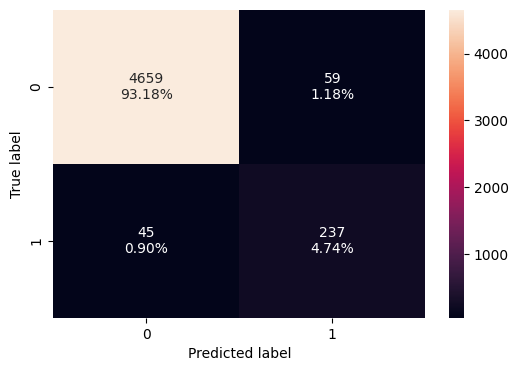

In [122]:
plot_confusion_matrix_and_print_classification_report(model_6, X_test, y_test)

- The model is highly accurate overall, driven by strong performance on the majority class (Class 0).
- For the minority class (Class 1), performance is decent but not as strong:
   - Recall (0.84) shows the model catches most positives, but still misses ~16%.
   - Precision (0.80) means 20% of predicted positives are false alarms.
- This imbalance is expected given the dataset’s skew (only ~5.5% positives).


# Actionable Insights & Recommendations

- This neural network model is very effective overall, with excellent majority class handling.
- For the minority class, performance is solid but could be improved.
- Next steps to boost minority class metrics:
  - Class weighting or focal loss to emphasize minority class.
  - Resampling techniques (SMOTE, undersampling majority).
  - Threshold tuning to balance precision vs. recall.


1. Leverage the Model for Majority Class Predictions
   - The model is extremely reliable at identifying non-events (Class 0).
   - This reduces false alarms and unnecessary interventions, saving operational costs.
2. Improve Minority Class Detection
   - Since Class 1 represents the “critical” cases (e.g., fraud, defects, failures, churn), missing ~16% of them could have significant business impact.
3. Recommendation:
   - Adjust decision thresholds to favor recall (catch more positives).
   - Use class weighting or focal loss to improve minority detection.
   - Consider resampling techniques (SMOTE, undersampling majority).
4. Operational Integration
   - Deploy the model as a decision-support tool, not a fully automated system.
   - Human review can be applied to minority class predictions to validate critical cases.
   - This hybrid approach maximizes efficiency while minimizing risk.
5. Continuous Monitoring
   - Track performance metrics over time, especially recall for Class 1.
   - Retrain periodically with new data to adapt to changing patterns.
   - Set up monitoring dashboards to detect drift or drops in minority class performance.
